# Cosmological Parameter Constraints with Galaxy Clusters adundances

## import packages

In [57]:
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
import time
from scipy.interpolate import RectBivariateSpline
import scipy.stats as stats
from scipy.stats import norm, poisson
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Assign Cosmological paramters
Fiducial cosmological parameters based on [Planck 2018 results. VI. Cosmological parameters ](https://arxiv.org/abs/1807.06209)

In [58]:
cosmo_fid = ccl.Cosmology(
    Omega_c=0.265, Omega_b=0.049, h=0.674, sigma8=0.811, n_s=0.965)

# -------------------------------------------------------------------
# omega_m adjustments
cosmo_high_Om = ccl.Cosmology(
    Omega_c=0.3, Omega_b=0.049, h=0.674, sigma8=0.811, n_s=0.965)

cosmo_low_Om = ccl.Cosmology(
    Omega_c=0.2, Omega_b=0.049, h=0.674, sigma8=0.811, n_s=0.965)

# -------------------------------------------------------------------
# sigma8 adjustments
cosmo_high_s8 = ccl.Cosmology(
    Omega_c=0.265, Omega_b=0.049, h=0.674, sigma8=0.9, n_s=0.965)

cosmo_low_s8 = ccl.Cosmology(
    Omega_c=0.265, Omega_b=0.049, h=0.674, sigma8=0.7, n_s=0.965)

# -------------------------------------------------------------------
# no dark energy
cosmo_no_DE = ccl.Cosmology(
    Omega_c=0.265, Omega_b=0.049, h=0.674, sigma8=0.811, n_s=0.965, Omega_k= 1 - 0.265 - 0.049)


## Halo Mass Function Graph
### Construct function

In [59]:
hmf_200c = ccl.halos.MassFuncTinker08(mass_def=ccl.halos.MassDef(200, 'matter'))

def plot_mass_functions(cosmo_dict, z, masses, fid_key='Fiducial'):
    plt.figure(figsize=(10, 6))
    a = 1.0 / (1.0 + z)
    
    for label, cosmo in cosmo_dict.items():
        nm = hmf_200c(cosmo, masses, a)
        if label == fid_key:
            plt.loglog(masses, nm, 'k-', linewidth=2.5, label=f'{label}', zorder=10)
        else:
            plt.loglog(masses, nm, label=label, alpha=0.8)
            
    plt.title(f"Halo Mass Function at z = {z}", fontsize=16)
    plt.xlabel(r"Halo Mass $ [M_{\odot}]$", fontsize=14)
    plt.ylabel(r"$dn/d\log M [Mpc^{-3}M_{\odot}^{-1}]$", fontsize=14)
    plt.legend(fontsize=13,loc='lower left')
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


### Effect of Varying Model to Halo Mass Function

#### Fiducial

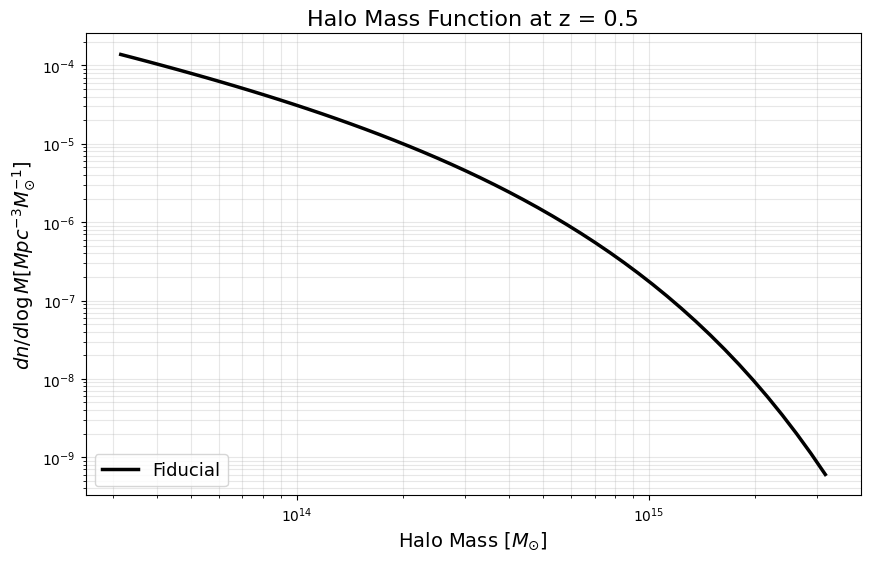

In [60]:
models = {
    'Fiducial': cosmo_fid
}

# --- Plotting ---
mass_range = np.logspace(13.5, 15.5, 50)
plot_mass_functions(models, z=0.5, masses=mass_range, fid_key='Fiducial')

#### Vary $\Omega_m$

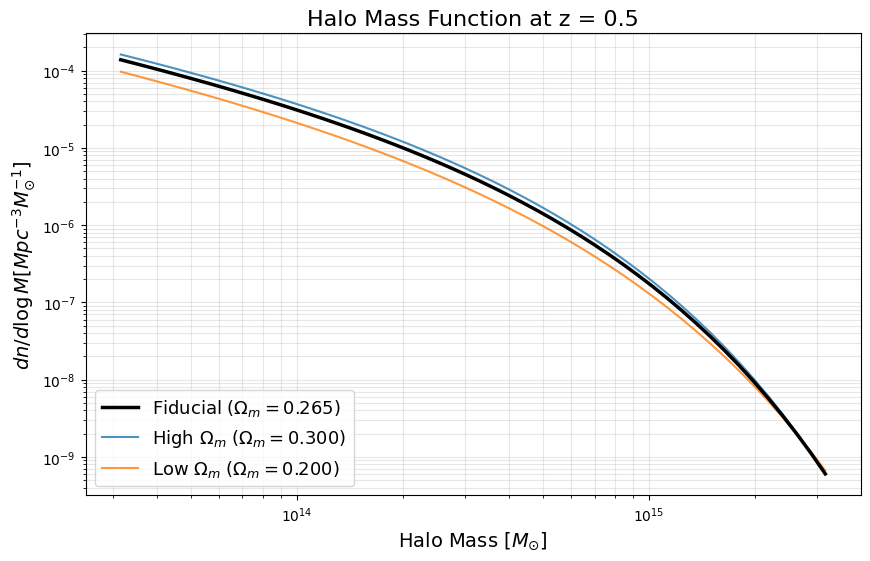

In [61]:
models_1 = {
    'Fiducial ($\\Omega_m = 0.265$)': cosmo_fid,
    'High $\\Omega_m$ ($\\Omega_m = 0.300$)': ccl.Cosmology(Omega_c=0.3, Omega_b=0.049, h=0.674, sigma8=0.811, n_s=0.965, Omega_k= 1 - 0.3 - 0.049 - 0.686),
    'Low $\\Omega_m$ ($\\Omega_m = 0.200$)': ccl.Cosmology(Omega_c=0.2, Omega_b=0.049, h=0.674, sigma8=0.811, n_s=0.965, Omega_k= 1 - 0.2 - 0.049 - 0.686),
}

# --- Run Plotting ---
mass_range = np.logspace(13.5, 15.5, 50)
plot_mass_functions(models_1, z=0.5, masses=mass_range, fid_key='Fiducial ($\\Omega_m = 0.265$)')

#### Vary $\sigma_8$

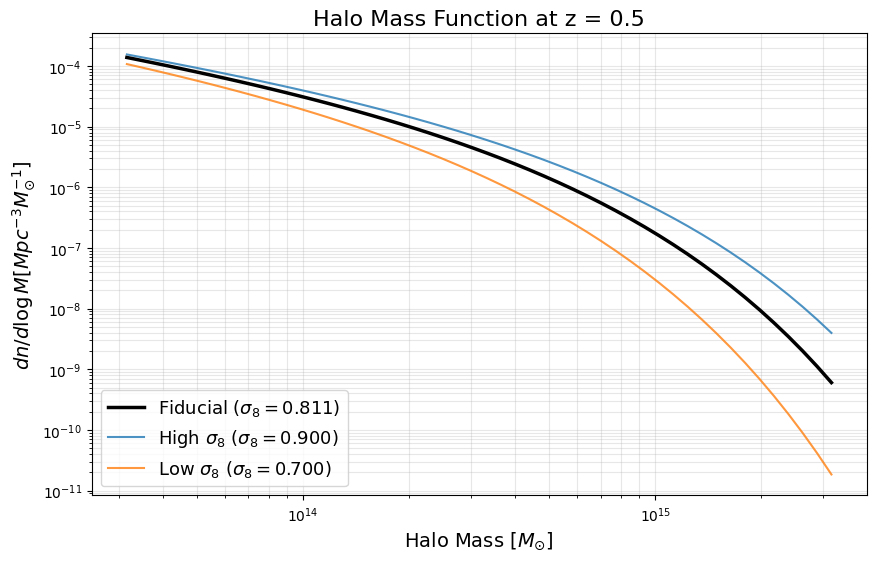

In [62]:
# Variations
models_2 = {
    'Fiducial ($\\sigma_8 = 0.811$)': cosmo_fid,
    'High $\\sigma_8$ ($\\sigma_8 = 0.900$)': ccl.Cosmology(Omega_c=0.265, Omega_b=0.049, h=0.674, sigma8=0.9, n_s=0.965),
    'Low $\\sigma_8$ ($\\sigma_8 = 0.700$)': ccl.Cosmology(Omega_c=0.265, Omega_b=0.049, h=0.674, sigma8=0.7, n_s=0.965)
}

# --- Run Plotting ---
mass_range = np.logspace(13.5, 15.5, 50)
plot_mass_functions(models_2, z=0.5, masses=mass_range, fid_key='Fiducial ($\\sigma_8 = 0.811$)')

#### Compare with no Dark energy model

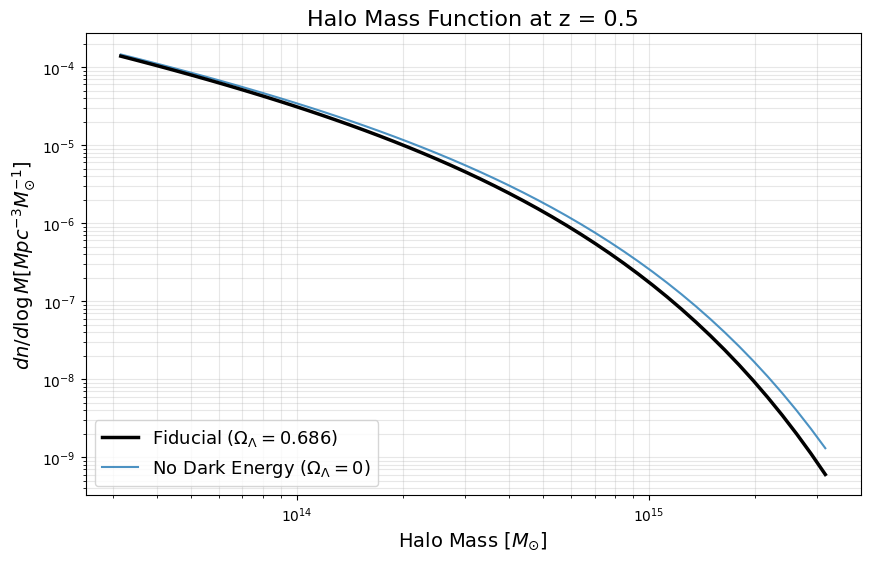

In [63]:
models_3 = {
    'Fiducial ($\\Omega_\\Lambda = 0.686$)': cosmo_fid,
    'No Dark Energy ($\\Omega_\\Lambda = 0$)': ccl.Cosmology(Omega_c=0.265, Omega_b=0.049, h=0.674, sigma8=0.811, n_s=0.965, 
                                    Omega_k=1 - 0.265 - 0.049)
}

# --- Plotting ---
mass_range = np.logspace(13.5, 15.5, 50)
plot_mass_functions(models_3, z=0.5, masses=mass_range, fid_key='Fiducial ($\\Omega_\\Lambda = 0.686$)')

## Confidence Contour: Absolute Mass Case
In this case, the halo mass is assumed to be deterministic, i.e., no mass–observable relation (mass proxy) is taken into account.

### Construct function to calculate number counts
For galaxy cluster surveys covering a sky area $\Omega_{\text{sky}}$, a redshift bin $[z_{\min}, z_{\max}]$, and a mass bin $[\ln M_{\min}, \ln M_{\max}]$, the cluster counts can be computed as

$$
N = \Omega_{\text{sky}}
\int_{z_{\min}}^{z_{\max}} dz \,
\frac{dV}{dz\, d\Omega}
\int_{\ln M_{\min}}^{\ln M_{\max}} d\ln M \,
\frac{dn}{d\ln M}.
$$

where the comoving volume element per unit redshift and solid angle is given by

$$
\frac{dV}{dz\, d\Omega} = \frac{c \, \chi^2(z)}{H(z)},
$$

and $\chi(z)$ is the comoving distance.

In [64]:
hmf_model = hmf_200c

def predict_cluster_counts(cosmo, survey_area_deg2, z_range, log_mass_range, z_steps=20, m_steps=30):
    z_min, z_max = z_range
    logM_min, logM_max = log_mass_range
    survey_solid_angle = survey_area_deg2 * (np.pi / 180)**2
    
    z_arr = np.linspace(z_min, z_max, z_steps)
    a_arr = 1.0 / (1.0 + z_arr)
    
    log10_M_arr = np.linspace(logM_min, logM_max, m_steps)
    M_arr = 10**log10_M_arr

    dN_dz = []
    c_light_kms = ccl.physical_constants.CLIGHT / 1000.0 

    for a in a_arr:
        dn_dlogM = hmf_model(cosmo, M_arr, a)
        n_z = simpson(dn_dlogM, x=log10_M_arr)

        chi = ccl.comoving_radial_distance(cosmo, a) 
        H_z = ccl.h_over_h0(cosmo, a) * cosmo['h'] * 100.0 
        
        dV_dz_dOmega = (c_light_kms * chi**2) / H_z
        dN_dz.append(n_z * dV_dz_dOmega * survey_solid_angle)

    N_total = simpson(dN_dz, x=z_arr)
    
    return N_total

In [65]:
# ==========================================
# set up parameters
# ==========================================
z_min = 0.1
z_max = 0.3
logM_min, logM_max = 14.0, 16.0  
grid_size = 10 

Om_range = np.linspace(0.20, 0.4, grid_size)   
s8_range = np.linspace(0.70, 0.9, grid_size)  

Om_true = 0.314
s8_true = 0.811
h = 0.674
Ob = 0.049
ns = 0.965

### Number map and Iso-number line: 1 redshift bin

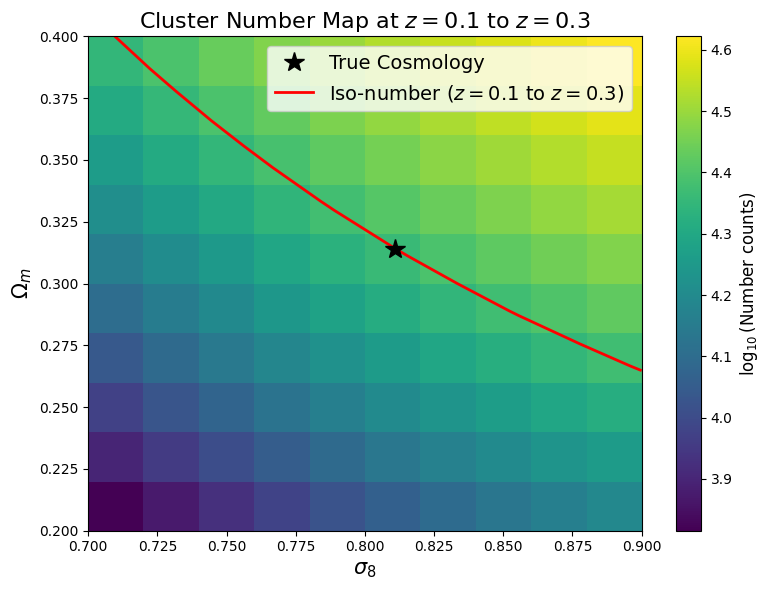

Elapsed Time: 119.4s


In [66]:
# ==========================================
# calculate density map
# ==========================================
start_time = time.time()

density_map = np.zeros((grid_size, grid_size))

for i, Om in enumerate(Om_range):
    for j, s8 in enumerate(s8_range):
        cosmo = ccl.Cosmology(
            Omega_c=Om - Ob, 
            Omega_b=Ob, 
            h=h, 
            sigma8=s8, 
            n_s=ns
        )
        density_map[i, j] = predict_cluster_counts(cosmo, survey_area_deg2=10000, z_range=(z_min, z_max), log_mass_range=(logM_min, logM_max))

true_density = predict_cluster_counts(cosmo_fid, survey_area_deg2=10000, z_range=(z_min, z_max), log_mass_range=(logM_min, logM_max))

# ==========================================
# Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))
extent = [s8_range.min(), s8_range.max(), Om_range.min(), Om_range.max()]
im = ax.imshow(np.log10(density_map), origin='lower', extent=extent, aspect='auto', cmap='viridis')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\log_{10}$(Number counts)', fontsize=12)

X, Y = np.meshgrid(s8_range, Om_range)

# Iso-number Line 
cs_true = ax.contour(X, Y, np.log10(density_map), levels=[np.log10(true_density)], 
                     colors='red', linewidths=2)

ax.plot(s8_true, Om_true, 'k*', markersize=15, label='True Cosmology')
ax.plot([], [], color='red', linewidth=2, label=f'Iso-number ($z={z_min}$ to $z={z_max}$)')
ax.set_xlabel(r'$\sigma_8$', fontsize=15)
ax.set_ylabel(r'$\Omega_m$', fontsize=15)
ax.set_title(f'Cluster Number Map at $z={z_min}$ to $z={z_max}$', fontsize=16)
ax.legend(loc='upper right', fontsize=14)
plt.tight_layout()
plt.show()

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

### Iso-number line: 2 redshift bin

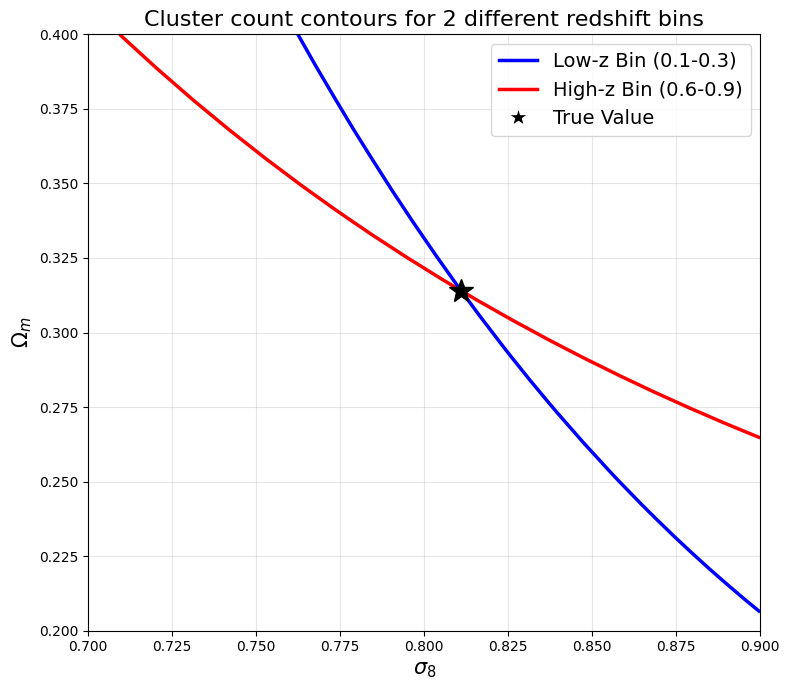

Elapsed Time: 621.4s


In [67]:
start_time = time.time()

bin1_z = (0.1, 0.3)  
bin2_z = (0.6, 0.9)  

logM_min = 14.0
logM_max = 16.0 

grid_size = 20  
Om_range = np.linspace(0.20, 0.4, grid_size)
s8_range = np.linspace(0.70, 0.90, grid_size)


map_bin1 = np.zeros((grid_size, grid_size))
map_bin2 = np.zeros((grid_size, grid_size))

for i, Om in enumerate(Om_range):
    for j, s8 in enumerate(s8_range):
        cosmo = ccl.Cosmology(
            Omega_c=Om - Ob, Omega_b=Ob, h=h, sigma8=s8, n_s=ns, 
        )
        
        map_bin1[i, j] = predict_cluster_counts(cosmo, survey_area_deg2=10000, z_range=bin1_z, log_mass_range=(logM_min, logM_max))
        map_bin2[i, j] = predict_cluster_counts(cosmo, survey_area_deg2=10000, z_range=bin2_z, log_mass_range=(logM_min, logM_max))

true_val_bin1 = predict_cluster_counts(cosmo_fid, survey_area_deg2=10000, z_range=bin1_z, log_mass_range=(logM_min, logM_max))
true_val_bin2 = predict_cluster_counts(cosmo_fid, survey_area_deg2=10000, z_range=bin2_z, log_mass_range=(logM_min, logM_max))

# ==========================================
# Plot
# ==========================================
fig, ax = plt.subplots(figsize=(8, 7))
X, Y = np.meshgrid(s8_range, Om_range)

cs1 = ax.contour(X, Y, map_bin1, levels=[true_val_bin1], colors='red', linewidths=2.5)
cs2 = ax.contour(X, Y, map_bin2, levels=[true_val_bin2], colors='blue', linewidths=2.5)

# True Parameter 
ax.plot(s8_true, Om_true, 'k*', markersize=18, label='True Cosmology', zorder=10)

legend_elements = [
    Line2D([0], [0], color='blue', lw=2.5, label=f'Low-z Bin ({bin1_z[0]}-{bin1_z[1]})'),
    Line2D([0], [0], color='red', lw=2.5, label=f'High-z Bin ({bin2_z[0]}-{bin2_z[1]})'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='k', markersize=15, label='True Value')
]

ax.set_xlabel(r'$\sigma_8$', fontsize=15)
ax.set_ylabel(r'$\Omega_m$', fontsize=15)
ax.set_title('Cluster count contours for 2 different redshift bins', fontsize=16)
ax.legend(handles=legend_elements, loc='upper right', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

### Iso-number line with uncertainty band: 2 redshift bin

In [68]:
# ==========================================
# Setup
# ==========================================
z1 = np.array([0.1, 0.3])
z2 = np.array([0.6, 0.9])
bins = [z1, z2]

survey_area_deg2 = 10000.0
log_mass_range = (14.0, 16.0)
grid_size = 20

# Cosmological Parameter 
Om_range = np.linspace(0.2, 0.4, grid_size)
s8_range = np.linspace(0.70, 0.90, grid_size)

<>:58: SyntaxWarning: invalid escape sequence '\p'
<>:58: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1169/4233708498.py:58: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title(f'Cluster counts contours for 2 different redshift bins with $\pm10\%$ error bands', fontsize=16)


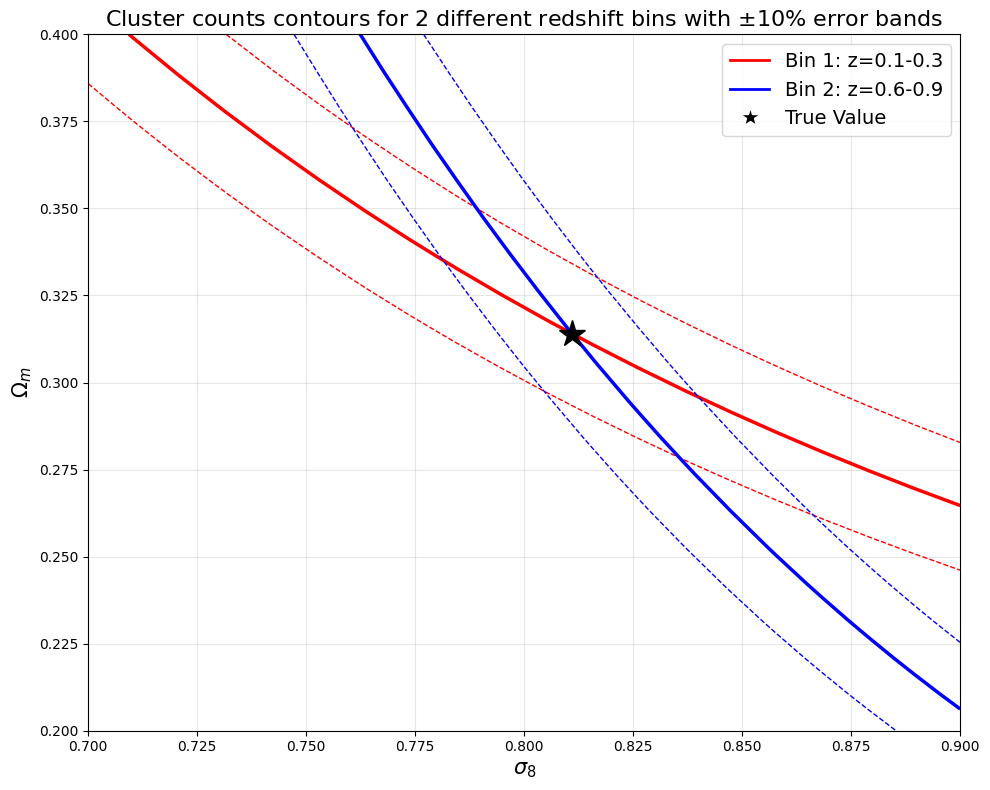

Elapsed Time: 584.0s


In [69]:
# ==========================================
# Generate true data
# ==========================================
true_counts = []
for z_r in bins:
    N = predict_cluster_counts(cosmo_fid, survey_area_deg2, z_r, log_mass_range)
    true_counts.append(N)

# ==========================================
# Grid Search
# ==========================================
model_counts_map = np.zeros((grid_size, grid_size, len(bins)))

start_time = time.time()

for i, Om in enumerate(Om_range):
    for j, s8 in enumerate(s8_range):
        cosmo = ccl.Cosmology(
            Omega_c=Om-Ob, Omega_b=Ob, h=h, sigma8=s8, n_s=ns, 
        )
        
        for k, z_r in enumerate(bins):
            N_model = predict_cluster_counts(cosmo, survey_area_deg2, z_r, log_mass_range)
            model_counts_map[i, j, k] = N_model

# ==========================================
# Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

X, Y = np.meshgrid(s8_range, Om_range)
colors = ['red', 'blue']

lines = []
labels = []

for k in range(len(bins)):
    z_min, z_max = bins[k]
    Z_bin = model_counts_map[:, :, k]
    N_true = true_counts[k]
    
    ax.contour(X, Y, Z_bin, levels=[N_true], colors=[colors[k]], linewidths=2.5)
    
    levels_extra = [N_true * 0.9, N_true * 1.1] 
    ax.contour(X, Y, Z_bin, levels=levels_extra, colors=[colors[k]], linewidths=1, linestyles='--')
    
    proxy = plt.Line2D([0], [0], 
                       color=colors[k], 
                       linewidth=2, 
                       label=f'Bin {k+1}: z={z_min:.1f}-{z_max:.1f}')
    lines.append(proxy)

ax.plot(s8_true, Om_true, 'k*', markersize=20, label='True Cosmology', zorder=10)
lines.append(plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='k', markersize=15))

ax.set_xlabel(r'$\sigma_8$', fontsize=15)
ax.set_ylabel(r'$\Omega_m$', fontsize=15)
ax.set_title(f'Cluster counts contours for 2 different redshift bins with $\pm10\%$ error bands', fontsize=16)
ax.legend(handles=lines, labels=[l.get_label() for l in lines[:-1]] + ['True Value'], 
          loc='upper right', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

### Confidence Contour using Likelihood Analysis
the confidence contours are derived using a Poisson likelihood function $\mathcal{L}$.

The log-likelihood is defined as

$$
\ln \mathcal{L}
= \sum_{i,j}
\left[
N_{ij} \ln \langle N_{ij} \rangle
- \langle N_{ij} \rangle
- \ln (N_{ij}!)
\right],
$$

where $N_{ij}$ is the observed number of clusters in the $(i,j)$-th redshift and mass bin, and $\langle N_{ij} \rangle$ is the theoretical expectation value predicted by the model.

**Note**: The likelihood is derived from the Poisson distribution under the assumption that cluster counts in each bin are independent.<br><br>

For computational convenience, the likelihood is converted into an effective chi-square statistic,

$$
\chi^2 = -2 \ln \mathcal{L},
$$

which is then used to construct confidence contours in the parameter space.

In [70]:
# ==========================================
# Setup
# ==========================================
bins = [np.array([0.1, 0.3]), np.array([0.6, 0.9])]
survey_area_deg2 = 10000.0
log_mass_range = (14.0, 16.0)

true_counts = [predict_cluster_counts(cosmo_fid, survey_area_deg2, z_r, log_mass_range) for z_r in bins]

#### Confidence Contour (Compare with each degeneracy line)

<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:79: SyntaxWarning: invalid escape sequence '\s'
<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:79: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1169/2550229696.py:78: SyntaxWarning: invalid escape sequence '\s'
  lines.append(plt.Line2D([0], [0], color='green', linestyle='-', linewidth=2, label='Joint $1\sigma$ Contour'))
/tmp/ipykernel_1169/2550229696.py:79: SyntaxWarning: invalid escape sequence '\s'
  lines.append(plt.Line2D([0], [0], color='green', linestyle='-', linewidth=1.25, label='Joint $2\sigma$ Contour'))


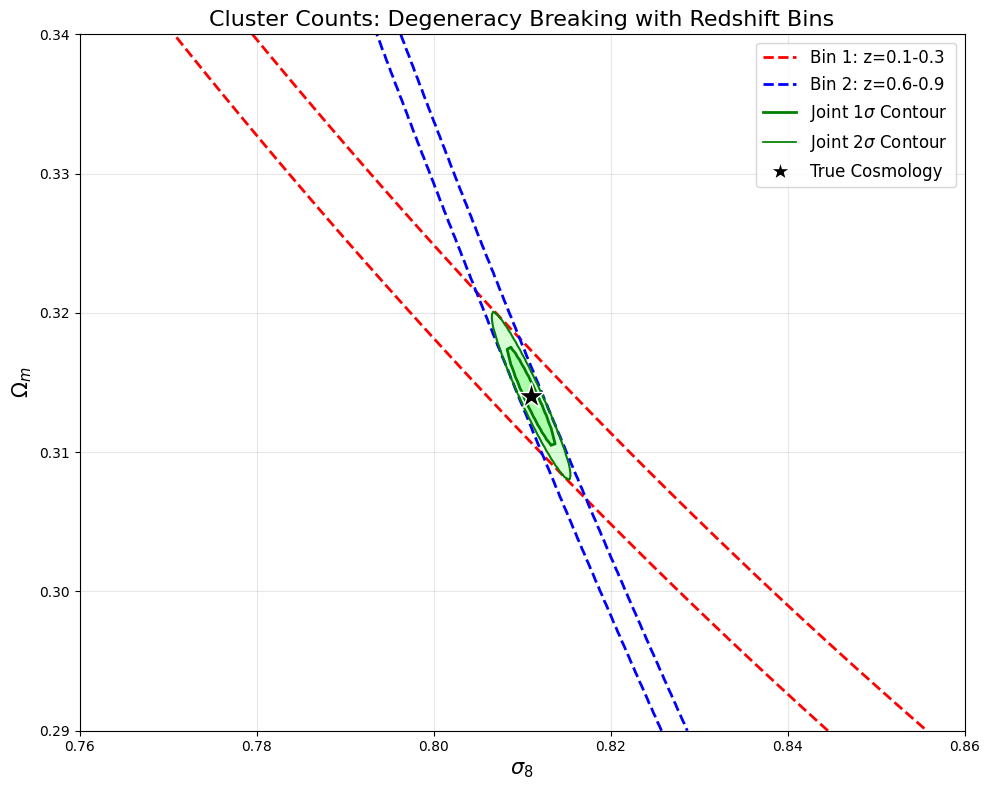

Elapsed Time: 494.6s


In [71]:
# ==========================================
# Grid Search 
# ==========================================
start_time = time.time()

grid_size_coarse = 20
Om_coarse = np.linspace(0.29, 0.34, grid_size_coarse)
s8_coarse = np.linspace(0.76, 0.86, grid_size_coarse)

logL_map_coarse = np.zeros((grid_size_coarse, grid_size_coarse))
logL_bins_coarse = [np.zeros((grid_size_coarse, grid_size_coarse)) for _ in bins]

for i, Om in enumerate(Om_coarse):
    for j, s8 in enumerate(s8_coarse):
        cosmo = ccl.Cosmology(Omega_c=Om-Ob, Omega_b=Ob, h=h, sigma8=s8, n_s=ns)
        
        for idx, z_r in enumerate(bins):
            N_model = predict_cluster_counts(cosmo, survey_area_deg2, z_r, log_mass_range)
            
            k_true = int(round(true_counts[idx])) 
            logL = stats.poisson.logpmf(k=k_true, mu=N_model)
            
            logL_bins_coarse[idx][i, j] = logL
            logL_map_coarse[i, j] += logL 

# Interpolation 
grid_size_fine = 200
Om_fine = np.linspace(0.29, 0.34, grid_size_fine)
s8_fine = np.linspace(0.76, 0.86, grid_size_fine)
X_fine, Y_fine = np.meshgrid(s8_fine, Om_fine)

# chi-squared of  joint likelihood
spline_map = RectBivariateSpline(Om_coarse, s8_coarse, logL_map_coarse)
logL_map_fine = spline_map(Om_fine, s8_fine)
logL_max = np.max(logL_map_fine)
chi2_map_fine = -2 * (logL_map_fine - logL_max)

# chi-squared for each bin
chi2_bins_fine = []
for idx in range(len(bins)):
    spline_bin = RectBivariateSpline(Om_coarse, s8_coarse, logL_bins_coarse[idx])
    logL_bin_fine = spline_bin(Om_fine, s8_fine)
    logL_bin_max = np.max(logL_bin_fine)
    chi2_bin = -2 * (logL_bin_fine - logL_bin_max)
    chi2_bins_fine.append(chi2_bin)

# ==========================================
# Plotting 
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

levels_1sigma = 2.30
levels_2sigma = 6.18

lines = []

# ----------------------------------------------------
# plot contour for each bin (2-sigma) with dashed lines
# ----------------------------------------------------
band_colors = ['red', 'blue']
for idx in range(len(bins)):
    # วาดเส้นขอบ 2-sigma เป็นเส้นประ
    ax.contour(X_fine, Y_fine, chi2_bins_fine[idx], levels=[levels_2sigma], 
               colors=[band_colors[idx]], linewidths=2, linestyles='--')
    
    proxy = plt.Line2D([0], [0], color=band_colors[idx], linewidth=2, linestyle='--',
                       label=f'Bin {idx+1}: z={bins[idx][0]:.1f}-{bins[idx][1]:.1f} ')
    lines.append(proxy)

# ----------------------------------------------------
# plot joint likelihood contours (1-sigma and 2-sigma) with solid lines
# ----------------------------------------------------
ax.contourf(X_fine, Y_fine, chi2_map_fine, levels=[0, levels_1sigma, levels_2sigma], 
            colors=['#99ff99', '#ccffcc'], alpha=0.8)
ax.contour(X_fine, Y_fine, chi2_map_fine, levels=[levels_1sigma, levels_2sigma], 
           colors=['green', 'green'], linewidths=[2, 1.5])

lines.append(plt.Line2D([0], [0], color='green', linestyle='-', linewidth=2, label='Joint $1\sigma$ Contour'))
lines.append(plt.Line2D([0], [0], color='green', linestyle='-', linewidth=1.25, label='Joint $2\sigma$ Contour'))

# ----------------------------------------------------
# true cosmology marker
# ----------------------------------------------------
ax.plot(s8_true, Om_true, 'k*', markersize=20, markeredgecolor='white', zorder=10)
lines.append(plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='k', markersize=15, label='True Cosmology'))

ax.set_xlabel(r'$\sigma_8$', fontsize=15)
ax.set_ylabel(r'$\Omega_m$', fontsize=15)
ax.set_title('Cluster Counts: Degeneracy Breaking with Redshift Bins', fontsize=16)

# จัดเรียง Legend
ax.legend(handles=lines, loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

#### Confidence Contour 

<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1169/992379554.py:56: SyntaxWarning: invalid escape sequence '\s'
  lines.append(plt.Line2D([0], [0], color='red', linestyle='-', linewidth=3, label='$1\sigma$'))
/tmp/ipykernel_1169/992379554.py:57: SyntaxWarning: invalid escape sequence '\s'
  lines.append(plt.Line2D([0], [0], color='red', linestyle='-', linewidth=1.5, label='$2\sigma$'))


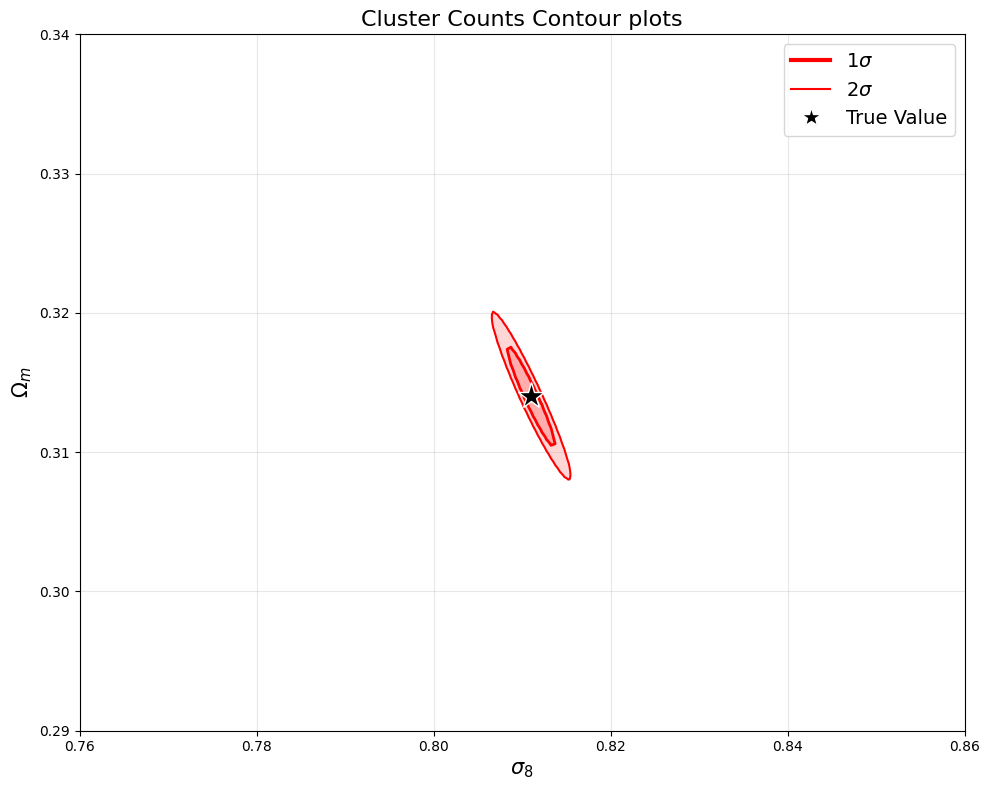

Elapsed Time: 586.9s


In [72]:
# ==========================================
# Grid Search 
# ==========================================
start_time = time.time()

grid_size_coarse = 20
Om_coarse = np.linspace(0.29, 0.34, grid_size_coarse)
s8_coarse = np.linspace(0.76, 0.86, grid_size_coarse)

logL_map_coarse = np.zeros((grid_size_coarse, grid_size_coarse))
logL_bins_coarse = [np.zeros((grid_size_coarse, grid_size_coarse)) for _ in bins]

for i, Om in enumerate(Om_coarse):
    for j, s8 in enumerate(s8_coarse):
        cosmo = ccl.Cosmology(Omega_c=Om-Ob, Omega_b=Ob, h=h, sigma8=s8, n_s=ns)
        
        for idx, z_r in enumerate(bins):
            N_model = predict_cluster_counts(cosmo, survey_area_deg2, z_r, log_mass_range)
            
            k_true = int(round(true_counts[idx])) 
            logL = stats.poisson.logpmf(k=k_true, mu=N_model)
            
            logL_bins_coarse[idx][i, j] = logL
            logL_map_coarse[i, j] += logL 

# ==========================================
# Interpolation 
# ==========================================
grid_size_fine = 200
Om_fine = np.linspace(0.29, 0.34, grid_size_fine)
s8_fine = np.linspace(0.76, 0.86, grid_size_fine)
X_fine_2, Y_fine_2 = np.meshgrid(s8_fine, Om_fine)

spline_map = RectBivariateSpline(Om_coarse, s8_coarse, logL_map_coarse)
logL_map_fine = spline_map(Om_fine, s8_fine)

# convert log-likelihood to chi-squared 
logL_max = np.max(logL_map_fine)
chi2_map_fine_2 = -2 * (logL_map_fine - logL_max)

# ==========================================
# Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['blue', 'green']
lines = []

# Plot Individual Bins (width)
levels_1sigma = 2.30
levels_2sigma = 6.18

# Filled Contours 
ax.contourf(X_fine_2, Y_fine_2, chi2_map_fine_2, levels=[0, levels_1sigma, levels_2sigma], colors=['#ff9999', '#ffcccc'], alpha=0.8)
ax.contour(X_fine_2, Y_fine_2, chi2_map_fine_2, levels=[levels_1sigma, levels_2sigma], colors=['red', 'red'], linewidths=[2, 1.5])

lines.append(plt.Line2D([0], [0], color='red', linestyle='-', linewidth=3, label='$1\sigma$'))
lines.append(plt.Line2D([0], [0], color='red', linestyle='-', linewidth=1.5, label='$2\sigma$'))

ax.plot(s8_true, Om_true, 'k*', markersize=20, markeredgecolor='white', zorder=10)
lines.append(plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='k', markersize=15, label='True Value'))

ax.set_xlabel(r'$\sigma_8$', fontsize=15)
ax.set_ylabel(r'$\Omega_m$', fontsize=15)
ax.set_title('Cluster Counts Contour plots', fontsize=16)
ax.legend(handles=lines, loc='upper right', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

#### Confidence Contour (Compare with wrong number counts)

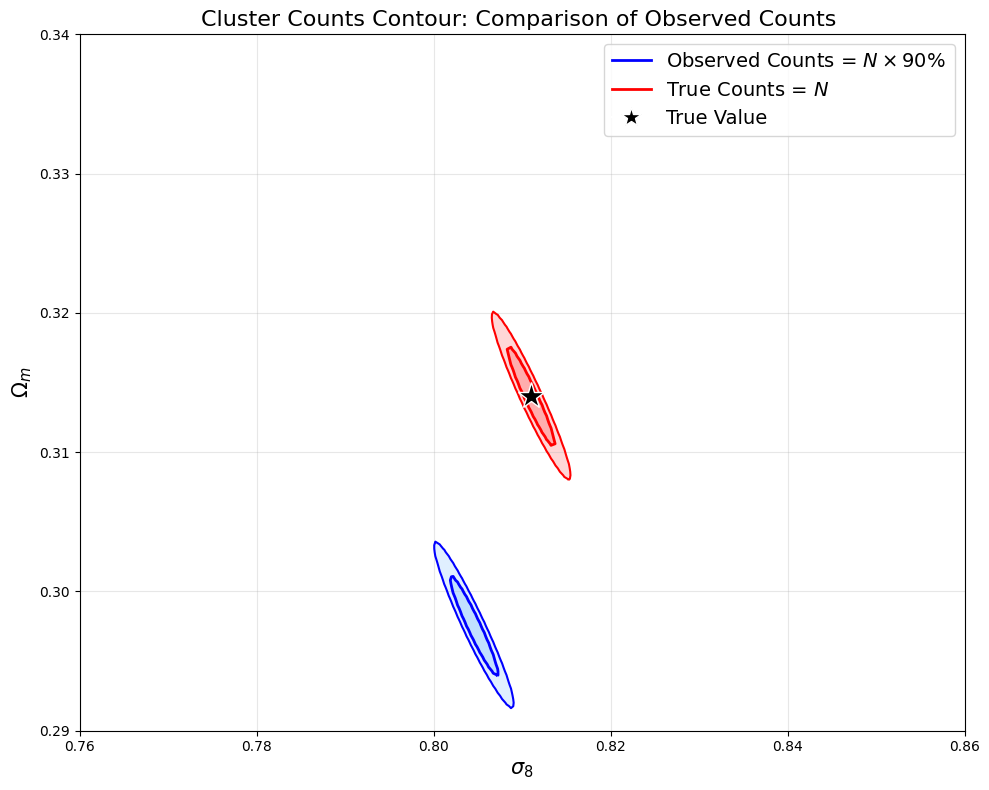

Elapsed Time: 678.8s


In [73]:
# ==========================================
# Setup 
# ==========================================
start_time = time.time()

bins = [np.array([0.1, 0.3]), np.array([0.6, 0.9])]
survey_area_deg2 = 10000.0
log_mass_range = (14.0, 16.0)


true_counts = [predict_cluster_counts(cosmo_fid, survey_area_deg2, z_r, log_mass_range) for z_r in bins]

true_counts_half = [count * 0.9 for count in true_counts]

# ==========================================
# Grid Search 
# ==========================================
grid_size_coarse = 20
Om_coarse = np.linspace(0.29, 0.34, grid_size_coarse)
s8_coarse = np.linspace(0.76, 0.86, grid_size_coarse)

logL_map_coarse = np.zeros((grid_size_coarse, grid_size_coarse))
logL_map_coarse_half = np.zeros((grid_size_coarse, grid_size_coarse))

start_time = time.time()

for i, Om in enumerate(Om_coarse):
    for j, s8 in enumerate(s8_coarse):
        cosmo = ccl.Cosmology(Omega_c=Om-Ob, Omega_b=Ob, h=h, sigma8=s8, n_s=ns)
        
        for idx, z_r in enumerate(bins):
            N_model = predict_cluster_counts(cosmo, survey_area_deg2, z_r, log_mass_range)
            
            k_true = int(round(true_counts[idx])) 
            logL = stats.poisson.logpmf(k=k_true, mu=N_model)
            logL_map_coarse[i, j] += logL 

            k_true_half = int(round(true_counts_half[idx]))
            logL_half = stats.poisson.logpmf(k=k_true_half, mu=N_model)
            logL_map_coarse_half[i, j] += logL_half

# ==========================================
# Interpolation 
# ==========================================
grid_size_fine = 200
Om_fine = np.linspace(0.29, 0.34, grid_size_fine)
s8_fine = np.linspace(0.76, 0.86, grid_size_fine)
X_fine_2, Y_fine_2 = np.meshgrid(s8_fine, Om_fine)

spline_map = RectBivariateSpline(Om_coarse, s8_coarse, logL_map_coarse)
logL_map_fine = spline_map(Om_fine, s8_fine)
chi2_map_fine_4 = -2 * (logL_map_fine - np.max(logL_map_fine))

spline_map_half = RectBivariateSpline(Om_coarse, s8_coarse, logL_map_coarse_half)
logL_map_fine_half = spline_map_half(Om_fine, s8_fine)
chi2_map_fine_half = -2 * (logL_map_fine_half - np.max(logL_map_fine_half))

# ==========================================
# Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))
lines = []

levels_1sigma = 2.30
levels_2sigma = 6.18

# ------------------------------------------
# Plot 1: Half Counts (N/1.5) - Blue shades
# ------------------------------------------
ax.contourf(X_fine_2, Y_fine_2, chi2_map_fine_half, 
            levels=[0, levels_1sigma, levels_2sigma], 
            colors=['#99ccff', '#cce5ff'], alpha=0.6)

ax.contour(X_fine_2, Y_fine_2, chi2_map_fine_half, 
           levels=[levels_1sigma, levels_2sigma], 
           colors=['blue', 'blue'], linestyles=['-', '-'], linewidths=[2, 1.5])

lines.append(plt.Line2D([0], [0], color='blue', linestyle='-', linewidth=2, label=r'Observed Counts = $N \times 90\%$ '))

# ------------------------------------------
# Plot 2: Original Counts (N) - Red shades
# ------------------------------------------
ax.contourf(X_fine_2, Y_fine_2, chi2_map_fine_4, 
            levels=[0, levels_1sigma, levels_2sigma], 
            colors=['#ff9999', '#ffcccc'], alpha=0.8)

ax.contour(X_fine_2, Y_fine_2, chi2_map_fine_4, 
           levels=[levels_1sigma, levels_2sigma], 
           colors=['red', 'red'], linestyles=['-', '-'], linewidths=[2, 1.5])

lines.append(plt.Line2D([0], [0], color='red', linestyle='-', linewidth=2, label='True Counts = $N$ '))

ax.plot(s8_true, Om_true, 'k*', markersize=20, markeredgecolor='white', zorder=10)
lines.append(plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='k', markersize=15, label='True Value'))

ax.set_xlabel(r'$\sigma_8$', fontsize=15)
ax.set_ylabel(r'$\Omega_m$', fontsize=15)
ax.set_title('Cluster Counts Contour: Comparison of Observed Counts ', fontsize=16)
ax.legend(handles=lines, loc='upper right', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

#### Confidence Contour (Compare with varying survey area)

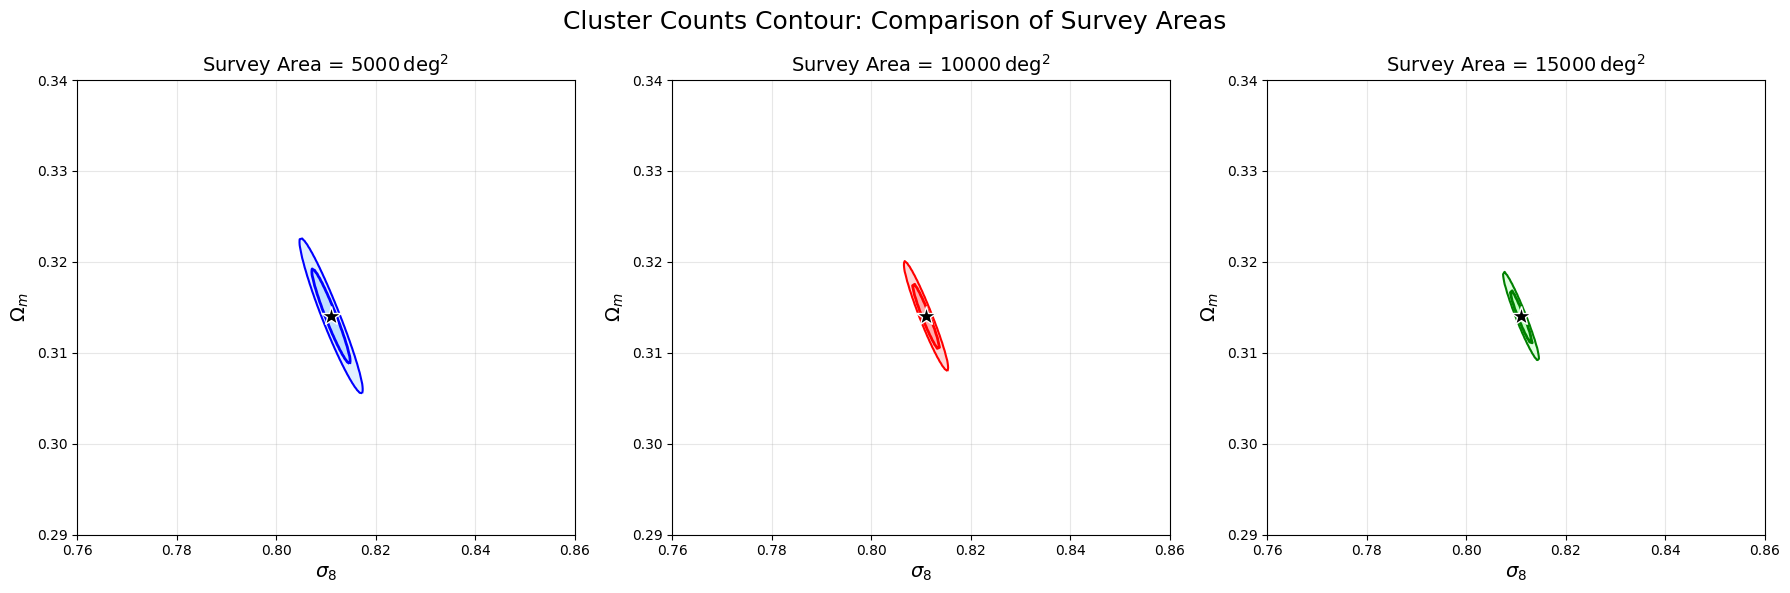

Elapsed Time: 618.3s


In [74]:
# ==========================================
# Setup 
# ==========================================
start_time = time.time()

bins = [np.array([0.1, 0.3]), np.array([0.6, 0.9])]
survey_area_deg2 = 10000.0
survey_area_deg2_s = 5000.0
survey_area_deg2_l = 15000.0
log_mass_range = (14.0, 16.0)

true_counts = [predict_cluster_counts(cosmo_fid, survey_area_deg2, z_r, log_mass_range) for z_r in bins]
true_counts_s = [predict_cluster_counts(cosmo_fid, survey_area_deg2_s, z_r, log_mass_range) for z_r in bins]
true_counts_l = [predict_cluster_counts(cosmo_fid, survey_area_deg2_l, z_r, log_mass_range) for z_r in bins]

grid_size_coarse = 20
Om_coarse = np.linspace(0.29, 0.34, grid_size_coarse)
s8_coarse = np.linspace(0.76, 0.86, grid_size_coarse)

logL_map_coarse = np.zeros((grid_size_coarse, grid_size_coarse))
logL_map_coarse_s = np.zeros((grid_size_coarse, grid_size_coarse))
logL_map_coarse_l = np.zeros((grid_size_coarse, grid_size_coarse))

start_time = time.time()

for i, Om in enumerate(Om_coarse):
    for j, s8 in enumerate(s8_coarse):
        cosmo = ccl.Cosmology(Omega_c=Om-Ob, Omega_b=Ob, h=h, sigma8=s8, n_s=ns)
        
        for idx, z_r in enumerate(bins):
            N_model = predict_cluster_counts(cosmo, survey_area_deg2, z_r, log_mass_range)
            N_model_s = predict_cluster_counts(cosmo, survey_area_deg2_s, z_r, log_mass_range)
            N_model_l = predict_cluster_counts(cosmo, survey_area_deg2_l, z_r, log_mass_range)
            
            k_true = int(round(true_counts[idx])) 
            logL = stats.poisson.logpmf(k=k_true, mu=N_model)
            logL_map_coarse[i, j] += logL 

            k_true_s = int(round(true_counts_s[idx]))
            logL_s = stats.poisson.logpmf(k=k_true_s, mu=N_model_s)
            logL_map_coarse_s[i, j] += logL_s

            k_true_l = int(round(true_counts_l[idx]))
            logL_l = stats.poisson.logpmf(k=k_true_l, mu=N_model_l)
            logL_map_coarse_l[i, j] += logL_l

grid_size_fine = 200
Om_fine = np.linspace(0.29, 0.34, grid_size_fine)
s8_fine = np.linspace(0.76, 0.86, grid_size_fine)
X_fine_2, Y_fine_2 = np.meshgrid(s8_fine, Om_fine)

spline_map = RectBivariateSpline(Om_coarse, s8_coarse, logL_map_coarse)
logL_map_fine = spline_map(Om_fine, s8_fine)
chi2_map_fine_4 = -2 * (logL_map_fine - np.max(logL_map_fine))

spline_map_s = RectBivariateSpline(Om_coarse, s8_coarse, logL_map_coarse_s)
logL_map_fine_s = spline_map_s(Om_fine, s8_fine)
chi2_map_fine_s = -2 * (logL_map_fine_s - np.max(logL_map_fine_s))

spline_map_l = RectBivariateSpline(Om_coarse, s8_coarse, logL_map_coarse_l)
logL_map_fine_l = spline_map_l(Om_fine, s8_fine)
chi2_map_fine_l = -2 * (logL_map_fine_l - np.max(logL_map_fine_l))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

levels_1sigma = 2.30
levels_2sigma = 6.18

# ------------------------------------------
# Plot 1: f=10000 - Red shades
# ------------------------------------------
axes[0].contourf(X_fine_2, Y_fine_2, chi2_map_fine_s, levels=[0, levels_1sigma, levels_2sigma], colors=['#99ccff', '#cce5ff'], alpha=0.6)
axes[0].contour(X_fine_2, Y_fine_2, chi2_map_fine_s, levels=[levels_1sigma, levels_2sigma], colors=['blue', 'blue'], linestyles=['-', '-'], linewidths=[2, 1.5])
axes[0].plot(s8_true, Om_true, 'k*', markersize=15, markeredgecolor='white', zorder=10)
axes[0].set_title(r'Survey Area = $5000 \, \mathrm{deg}^2$', fontsize=14)

# ------------------------------------------
# Plot 2: f=5000 - Blue shades
# ------------------------------------------
axes[1].contourf(X_fine_2, Y_fine_2, chi2_map_fine_4, levels=[0, levels_1sigma, levels_2sigma], colors=['#ff9999', '#ffcccc'], alpha=0.8)
axes[1].contour(X_fine_2, Y_fine_2, chi2_map_fine_4, levels=[levels_1sigma, levels_2sigma], colors=['red', 'red'], linestyles=['-', '-'], linewidths=[2, 1.5])
axes[1].plot(s8_true, Om_true, 'k*', markersize=15, markeredgecolor='white', zorder=10)
axes[1].set_title(r'Survey Area = $10000 \, \mathrm{deg}^2$', fontsize=14)

# ------------------------------------------
# Plot 3: f=15000 - Blue shades
# ------------------------------------------
axes[2].contourf(X_fine_2, Y_fine_2, chi2_map_fine_l, levels=[0, levels_1sigma, levels_2sigma], colors=['#99ff99', '#ccffcc'], alpha=0.6)
axes[2].contour(X_fine_2, Y_fine_2, chi2_map_fine_l, levels=[levels_1sigma, levels_2sigma], colors=['green', 'green'], linestyles=['-', '-'], linewidths=[2, 1.5])
axes[2].plot(s8_true, Om_true, 'k*', markersize=15, markeredgecolor='white', zorder=10)
axes[2].set_title(r'Survey Area = $15000 \, \mathrm{deg}^2$', fontsize=14)

for ax in axes:
    ax.set_xlabel(r'$\sigma_8$', fontsize=14)
    ax.set_ylabel(r'$\Omega_m$', fontsize=14)
    ax.grid(True, alpha=0.3)

plt.suptitle('Cluster Counts Contour: Comparison of Survey Areas', fontsize=18,)
plt.tight_layout()
plt.show()

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

## Confidence Contour with Mass–Observable Relation (Richness Case)
In this case, we include a mass–observable relation by using galaxy cluster richness $\lambda$ as the observable proxy for halo mass. The expected cluster number counts are then modified to include the conditional probability distribution $P(\lambda|M)$:

$$
N = \Omega_{\text{sky}}
\int_{z_{\min}}^{z_{\max}} dz \,
\frac{dV}{dz\, d\Omega}
\int_{\lambda_{\min}}^{\lambda_{\max}} d\lambda
\int_{0}^{\infty} d\ln M \,
\frac{dn}{d\ln M}
P(\lambda|M).
$$
<br><br>
The conditional probability $P(\lambda|M)$ is assumed to follow a log-normal distribution:

$$
P(\lambda|M)
=
\frac{1}{\sqrt{2\pi}\,\sigma_{\ln \lambda|M}}
\exp\left[
-\frac{\left(\ln \lambda - \langle \ln \lambda \rangle\right)^2}
{2\sigma^2_{\ln \lambda|M}}
\right],
$$

where $\sigma_{\ln \lambda|M}$ represents the intrinsic scatter in the richness–mass relation.

<br>
The mean relation between richness and halo mass is modeled as

$$
\langle \ln \lambda | M, z \rangle
= A + B \ln \left(\frac{M}{M_{\text{piv}}}\right)
+ C \ln \left(\frac{1+z}{1+z_{\text{pivot}}}\right),
$$

where $A$, $B$, and $C$ are scaling parameters, and $M_{\text{piv}}$ and $z_{\text{pivot}}$ are pivot values.

### Construct mass-richness relation function and set up

In [75]:
def mean_ln_lambda(M, z, A, B, C, M_pivot, z_pivot):
    return A + B * np.log(M / M_pivot) + C * np.log((1.0 + z) / (1.0 + z_pivot))

def p_lambda_given_M(lam, M, z, A, B, C, M_pivot, z_pivot, sigma_ln_lam):
    mean_ln_lam = mean_ln_lambda(M, z, A, B, C, M_pivot, z_pivot)
    pdf_ln_lam = norm.pdf(np.log(lam), loc=mean_ln_lam, scale=sigma_ln_lam)
    return pdf_ln_lam / lam

def fraction_richness_bin(lam_min, lam_max, M, z, A, B, C, M_pivot, z_pivot, sigma_ln_lam):
    mean_ln_lam = mean_ln_lambda(M, z, A, B, C, M_pivot, z_pivot)
    cdf_max = norm.cdf(np.log(lam_max), loc=mean_ln_lam, scale=sigma_ln_lam)
    cdf_min = norm.cdf(np.log(lam_min), loc=mean_ln_lam, scale=sigma_ln_lam)
    
    return cdf_max - cdf_min

Fiducial Scaling Relation Parameters based on [Murata et al. (2019)](https://arxiv.org/abs/1904.07524)

In [76]:
# ==========================================
# Assign Fiducial Scaling Relation Parameters
# ==========================================
A_fid = 3.15            # Amplitude
B_fid = 0.86            # Mass slope
C_fid = -0.21           # Redshift evolution slope
M_pivot_fid = 3e14      # Pivot mass [M_sun]
z_pivot_fid = 0.6       # Pivot redshift
sigma_ln_lam_fid = 0.25 # Intrinsic scatter in ln(lambda)

true_scaling = (A_fid, B_fid, C_fid, M_pivot_fid, z_pivot_fid, sigma_ln_lam_fid)

### Richness-Mass Probability Distribution Plot

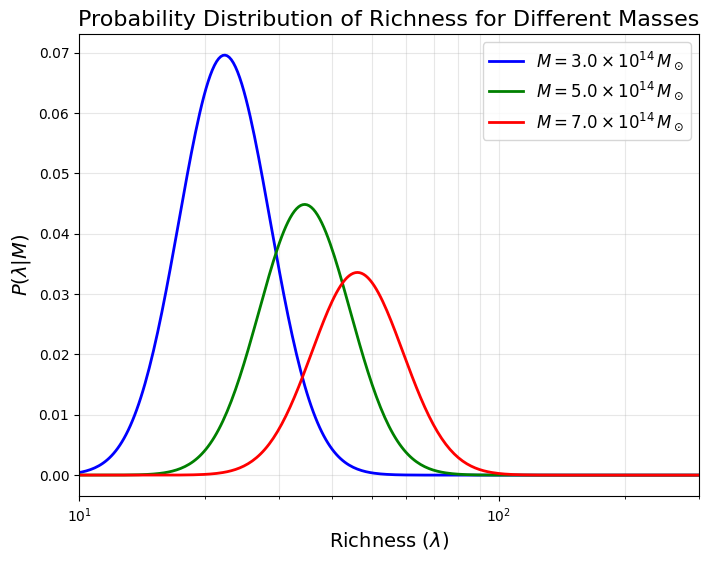

In [77]:
lam_array = np.logspace(0, 2.5, 500) 

masses_to_plot = [3e14, 5e14, 7e14]
colors = ['blue', 'green', 'red']

plt.figure(figsize=(8, 6))

for M, col in zip(masses_to_plot, colors):
    p_lam = p_lambda_given_M(
        lam_array, M, z=0.5, 
        A=A_fid, B=B_fid, C=C_fid, 
        M_pivot=M_pivot_fid, z_pivot=z_pivot_fid, 
        sigma_ln_lam=sigma_ln_lam_fid
    )
    
    exp = int(np.floor(np.log10(M)))
    base = M / 10**exp
    
    plt.plot(
        lam_array, p_lam,
        color=col, lw=2,
        label=rf'$M = {base:.1f} \times 10^{{{exp}}}\, M_\odot$'
    )

plt.xlabel(r'Richness ($\lambda$)', fontsize=14)
plt.ylabel(r'$P(\lambda | M)$', fontsize=14)
plt.title('Probability Distribution of Richness for Different Masses', fontsize=16)
plt.legend(fontsize=12)
plt.xscale('log')
plt.grid(True, which="both", alpha=0.3)
plt.xlim(10, 300)
plt.show()

### Construct function to calculate number counts 

In [85]:
def calculate_mass_range_from_richness(lam_range, z_range, scaling_params, n_sigma=3.0):
    lam_min, lam_max = lam_range
    z_min, z_max = z_range
    A, B, C, M_piv, z_piv, sigma_ln_lam = scaling_params
    
    # Capturing low-mass clusters that up-scatter 
    ln_lam_min_expanded = np.log(lam_min) 
    ln_lam_max_expanded = np.log(lam_max) 
    
    def get_ln_M(ln_lam, z):
        term_z = C * np.log((1.0 + z) / (1.0 + z_piv))
        ln_M = (ln_lam - A - term_z) / B + np.log(M_piv)
        return ln_M

    ln_M_corners = [
        get_ln_M(ln_lam_min_expanded, z_min),
        get_ln_M(ln_lam_min_expanded, z_max),
        get_ln_M(ln_lam_max_expanded, z_min),
        get_ln_M(ln_lam_max_expanded, z_max)
    ]
    
    ln_M_min_required = min(ln_M_corners)
    ln_M_max_required = max(ln_M_corners)
    
    log10_M_min = ln_M_min_required / np.log(10)
    log10_M_max = ln_M_max_required / np.log(10)
        
    return (log10_M_min, log10_M_max)

def number_density_bin(lam_min, lam_max, z, cosmo, M_array, A, B, C, M_pivot, z_pivot, sigma_ln_lam):
    a = 1.0 / (1.0 + z)
    
    dn_dlogM = hmf_model(cosmo, M_array, a)
    prob_bin = fraction_richness_bin(lam_min, lam_max, M_array, z, A, B, C, M_pivot, z_pivot, sigma_ln_lam)
    integrand = dn_dlogM * prob_bin
    logM_array = np.log10(M_array)
    n_z = simpson(integrand, x=logM_array)
    
    return n_z

def total_cluster_counts_richness(cosmo, survey_area_deg2, z_range, lam_range, scaling_params, z_steps=100, m_steps=100):
    z_min, z_max = z_range
    lam_min, lam_max = lam_range
    A, B, C, M_pivot, z_pivot, sigma_ln_lam = scaling_params
    logM_min, logM_max = calculate_mass_range_from_richness(lam_range, z_range, scaling_params, n_sigma=3.0)
    log10_M_arr = np.linspace(logM_min, logM_max, m_steps)
    survey_solid_angle = survey_area_deg2 * (np.pi / 180)**2
    z_arr = np.linspace(z_min, z_max, z_steps)
    a_arr = 1.0 / (1.0 + z_arr)
    M_arr = 10**log10_M_arr
    dN_dz = []
    c_light_kms = ccl.physical_constants.CLIGHT / 1000.0 

    for i, a in enumerate(a_arr):
        n_z = number_density_bin(lam_min, lam_max, z_arr[i], cosmo, M_arr, A, B, C, M_pivot, z_pivot, sigma_ln_lam)
        chi = ccl.comoving_radial_distance(cosmo, a) 
        H_z = ccl.h_over_h0(cosmo, a) * cosmo['h'] * 100.0 
        dV_dz_dOmega = (c_light_kms * chi**2) / H_z
        dN_dz.append(n_z * dV_dz_dOmega * survey_solid_angle)

    N_total = simpson(dN_dz, x=z_arr)
    
    return N_total

In [86]:
# =========
# Example 
# =========

# Define parameters
survey_area = 5000.0               
z_range = (0.2, 0.3)         
log_mass_range = (13.5, 15.5) 
lam_range = (20.0, 30.0)      

# Scaling parameters : (A, B, C, M_pivot, z_pivot, sigma_ln_lam)
scaling_params = (3.0, 1.0, 0.0, 3e14, 0.5, 0.25)

N_expected = total_cluster_counts_richness(
    cosmo=cosmo_fid, 
    survey_area_deg2=survey_area, 
    z_range=z_range, 
    lam_range=lam_range, 
    scaling_params=scaling_params,
    z_steps=50, 
    m_steps=100
)

log_mass_range = calculate_mass_range_from_richness(lam_range, (0.2, 0.9), true_scaling)
log_mass_range = tuple(float(x) for x in log_mass_range)

print(f"Richness Bin : [{min(lam_range):.1f}, {max(lam_range):.1f}]")
print(f"Redshift Bin : [{min(z_range):.2f}, {max(z_range):.2f}]")
print(f"Calculated log10(M) range to capture richness range [{round(lam_range[0], 1)}, {round(lam_range[1], 1)}]: {log_mass_range}")
print(f"Expected Number of Clusters: {N_expected:.2f}")

Richness Bin : [20.0, 30.0]
Redshift Bin : [0.20, 0.30]
Calculated log10(M) range to capture richness range [20.0, 30.0]: (14.368708746558026, 14.622198808867067)
Expected Number of Clusters: 361.63


### Confidence Contour using mass-richness relation

<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:86: SyntaxWarning: invalid escape sequence '\s'
<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:86: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1169/4112812642.py:85: SyntaxWarning: invalid escape sequence '\s'
  lines.append(plt.Line2D([0], [0], color='red', linestyle='-', linewidth=3, label='$1\sigma$'))
/tmp/ipykernel_1169/4112812642.py:86: SyntaxWarning: invalid escape sequence '\s'
  lines.append(plt.Line2D([0], [0], color='red', linestyle='-', linewidth=1.5, label='$2\sigma$'))


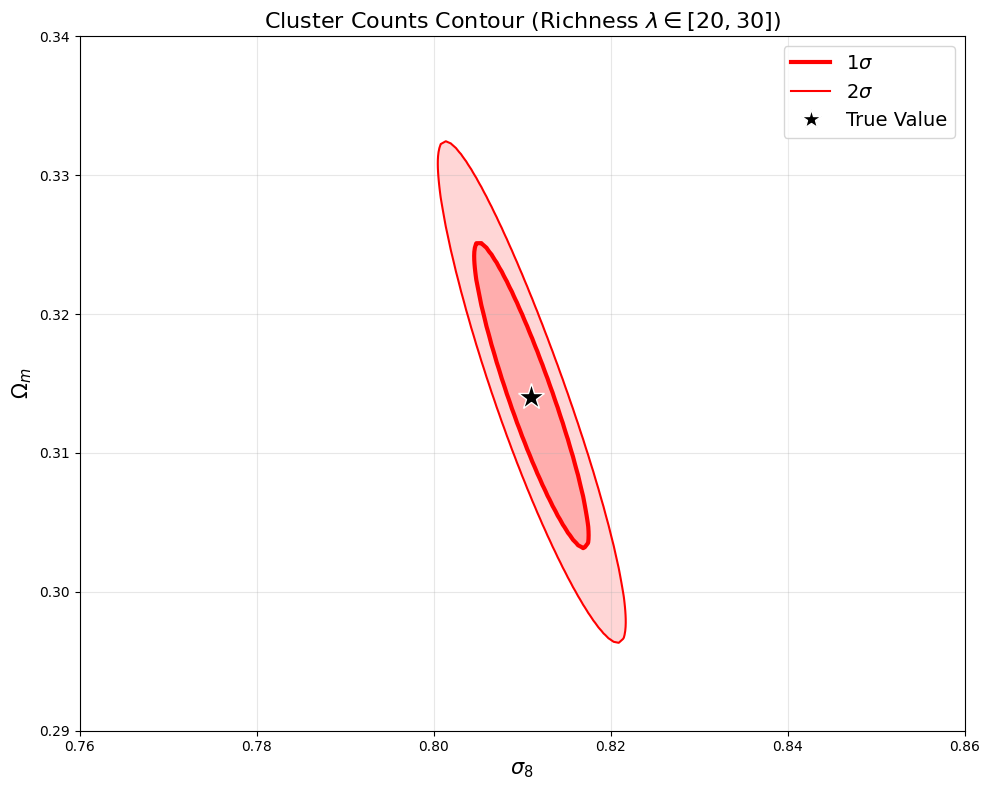

Elapsed Time: 571.5s


In [98]:
# ==========================================
# Setup Parameters
# ==========================================
start_time = time.time()

z_bins = [(0.1, 0.3), (0.6, 0.9)]
survey_area_deg2 = 10000

# Richness parameters
lam_range = (20.0, 30.0)
fiducial_scaling_params = (3.15, 0.86, -0.21, 3e14, 0.6, 0.25)

true_counts = []
for z_r in z_bins:
    N_true = total_cluster_counts_richness(
        cosmo=cosmo_fid, 
        survey_area_deg2=survey_area_deg2, 
        z_range=z_r, 
        lam_range=lam_range, 
        scaling_params=fiducial_scaling_params,
        z_steps=50, 
        m_steps=100
    )
    true_counts.append(N_true)

# ==========================================
# Grid Search 
# ==========================================
grid_size_coarse = 20 
Om_coarse = np.linspace(0.29, 0.34, grid_size_coarse)
s8_coarse = np.linspace(0.76, 0.86, grid_size_coarse)

logL_map_coarse = np.zeros((grid_size_coarse, grid_size_coarse))
logL_bins_coarse = [np.zeros((grid_size_coarse, grid_size_coarse)) for _ in z_bins]

start_time = time.time()

for i, Om in enumerate(Om_coarse):
    for j, s8 in enumerate(s8_coarse):
        cosmo = ccl.Cosmology(Omega_c=Om-Ob, Omega_b=Ob, h=h, sigma8=s8, n_s=ns)
        
        for idx, z_r in enumerate(z_bins):
            N_model = total_cluster_counts_richness(
                cosmo=cosmo, 
                survey_area_deg2=survey_area_deg2, 
                z_range=z_r, 
                lam_range=lam_range, 
                scaling_params=fiducial_scaling_params,
                z_steps=15, 
                m_steps=30  
            )
            
            k_true = int(round(true_counts[idx])) 
            logL = stats.poisson.logpmf(k=k_true, mu=N_model)

            logL_bins_coarse[idx][i, j] = logL
            logL_map_coarse[i, j] += logL 

# ==========================================
# Interpolation 
# ==========================================
grid_size_fine = 175
Om_fine = np.linspace(0.29, 0.34, grid_size_fine)
s8_fine = np.linspace(0.76, 0.86, grid_size_fine)
X_fine_2, Y_fine_2 = np.meshgrid(s8_fine, Om_fine)

spline_map = RectBivariateSpline(Om_coarse, s8_coarse, logL_map_coarse)
logL_map_fine = spline_map(Om_fine, s8_fine)

logL_max = np.max(logL_map_fine)
chi2_map_fine_7 = -2 * (logL_map_fine - logL_max)

# ==========================================
# Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))
lines = []

levels_1sigma = 2.30
levels_2sigma = 6.18

ax.contourf(X_fine_2, Y_fine_2, chi2_map_fine_7, levels=[0, levels_1sigma, levels_2sigma], colors=['#ff9999', '#ffcccc'], alpha=0.8)
ax.contour(X_fine_2, Y_fine_2, chi2_map_fine_7, levels=[levels_1sigma, levels_2sigma], colors=['red', 'red'], linewidths=[3, 1.5])

lines.append(plt.Line2D([0], [0], color='red', linestyle='-', linewidth=3, label='$1\sigma$'))
lines.append(plt.Line2D([0], [0], color='red', linestyle='-', linewidth=1.5, label='$2\sigma$'))

ax.plot(s8_true, Om_true, 'k*', markersize=20, markeredgecolor='white', zorder=10)
lines.append(plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='k', markersize=15, label='True Value'))

ax.set_xlabel(r'$\sigma_8$', fontsize=15)
ax.set_ylabel(r'$\Omega_m$', fontsize=15)
ax.set_title(rf'Cluster Counts Contour (Richness $\lambda \in [{lam_range[0]:.0f}, {lam_range[1]:.0f}]$)', fontsize=16)
ax.legend(handles=lines, loc='upper right', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
print(f"Elapsed Time: {time.time() - start_time:.1f}s")

### Confidence Contours with Varying Mass–Richness Relation Parameters

In this section, we investigate the impact of the mass–richness relation parameters on the resulting confidence contours. Specifically, we vary the parameters of the richness–mass scaling relation and examine how the inferred cosmological constraints change.

#### Set up coarse parameter space

In [88]:
grid_size_coarse = 20
Om_coarse = np.linspace(0.29, 0.34, grid_size_coarse)
s8_coarse = np.linspace(0.76, 0.86, grid_size_coarse)

##### Construct function to compare confidence contour

In [92]:
survey_area = 10000
z_bins = [(0.1, 0.3), (0.6, 0.9)]
lam_range = (20.0, 30.0)

true_counts = []
for z_r in z_bins:
    N_true = total_cluster_counts_richness(cosmo_fid, survey_area, z_r, lam_range, true_scaling)
    true_counts.append(N_true)
    
def generate_mock_richness(M_array, z_array, A, B, C, M_pivot, z_pivot, sigma_ln_lam):
    mean_ln_lam = A + B * np.log(M_array / M_pivot) + C * np.log((1.0 + z_array) / (1.0 + z_pivot))
    mock_ln_lam = np.random.normal(loc=mean_ln_lam, scale=sigma_ln_lam)  
    return mean_ln_lam, mock_ln_lam

def Plot_scaling(test_scaling_params, title_suffix=""):
    A_t, B_t, C_t, Mp, zp, sig_t = true_scaling
    A_b, B_b, C_b, _, _, sig_b = test_scaling_params

    grid_size = 18
    Om_grid = np.linspace(0.2, 0.4, grid_size)
    s8_grid = np.linspace(0.7, 0.9, grid_size)
    logL_map_test = np.zeros((grid_size, grid_size))
    logL_map_true = np.zeros((grid_size, grid_size))
  
    for i, Om in enumerate(Om_grid):
        for j, s8 in enumerate(s8_grid):
            cosmo_test = ccl.Cosmology(Omega_c=Om-Ob, Omega_b=Ob, h=h, sigma8=s8, n_s=ns)
            for idx, z_r in enumerate(z_bins):
                N_model_test = total_cluster_counts_richness(cosmo_test, survey_area, z_r, lam_range, test_scaling_params)
                logL_map_test[i, j] += poisson.logpmf(k=int(round(true_counts[idx])), mu=N_model_test)
                
                N_model_true = total_cluster_counts_richness(cosmo_test, survey_area, z_r, lam_range, true_scaling)
                logL_map_true[i, j] += poisson.logpmf(k=int(round(true_counts[idx])), mu=N_model_true)

    fine_size = 100
    Om_fine = np.linspace(0.2, 0.4, fine_size)
    s8_fine = np.linspace(0.7, 0.9, fine_size)
    X_fine, Y_fine = np.meshgrid(s8_fine, Om_fine)
    
    spline_test = RectBivariateSpline(Om_grid, s8_grid, logL_map_test)
    logL_fine_test = spline_test(Om_fine, s8_fine)
    chi2_map_test = -2 * (logL_fine_test - np.max(logL_fine_test))
    
    spline_true = RectBivariateSpline(Om_grid, s8_grid, logL_map_true)
    logL_fine_true = spline_true(Om_fine, s8_fine)
    chi2_map_true = -2 * (logL_fine_true - np.max(logL_fine_true))

    # ================================================================
    # Plotting 
    # ================================================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Subplot 1: Mass vs Richness (Fixed z) ---
    N_mock = 500
    M_mock = 10**(np.random.uniform(13.5, 15.5, N_mock))
    z_mock = np.random.uniform(0.2, 0.9, N_mock)

    _, obs_true = generate_mock_richness(M_mock, z_mock, A_t, B_t, C_t, Mp, zp, sig_t)
    _, obs_test = generate_mock_richness(M_mock, z_mock, A_b, B_b, C_b, Mp, zp, sig_b)
    
    axes[0].scatter(np.log(M_mock), obs_true, alpha=0.15, color='black', label=rf'True Clusters',zorder=3)
    axes[0].scatter(np.log(M_mock), obs_test, alpha=0.3, color='red', label=rf'Test Clusters',zorder=2)

    M_line = np.logspace(13.5, 15.5, 50)
    z_fixed = np.full_like(M_line, zp)
    mean_true_M, _ = generate_mock_richness(M_line, z_fixed, A_t, B_t, C_t, Mp, zp, sig_t)
    mean_bias_M, _ = generate_mock_richness(M_line, z_fixed, A_b, B_b, C_b, Mp, zp, sig_b)

    axes[0].plot(np.log(M_line), mean_true_M, 'k-', lw=3, label=rf'True Mean')
    axes[0].plot(np.log(M_line), mean_bias_M, 'r--', lw=3, label=rf'Test Mean')
    axes[0].set_xlabel(r'$\ln(M)$', fontsize=12)
    axes[0].set_ylabel(r'$\ln(\lambda)$', fontsize=12)
    axes[0].set_title(rf'Mass-Richness Relation (at $z={zp}$)', fontsize=14)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --- Subplot 2: Redshift vs Richness (Fixed M) ---
    z_line = np.linspace(0.2, 0.9, 50)
    M_fixed_for_z = np.full_like(z_line, Mp)

    mean_true_z, _ = generate_mock_richness(M_fixed_for_z, z_line, A_t, B_t, C_t, Mp, zp, sig_t)
    mean_bias_z, _ = generate_mock_richness(M_fixed_for_z, z_line, A_b, B_b, C_b, Mp, zp, sig_b)

    M_mock_fixed = np.full_like(z_mock, Mp) 
    _, obs_true_2 = generate_mock_richness(M_mock_fixed, z_mock, A_t, B_t, C_t, Mp, zp, sig_t)
    _, obs_test_2 = generate_mock_richness(M_mock_fixed, z_mock, A_b, B_b, C_b, Mp, zp, sig_b)
    
    axes[1].scatter(z_mock, obs_true_2, alpha=0.15, color='black', label=rf'True Clusters',zorder=3)
    axes[1].scatter(z_mock, obs_test_2, alpha=0.3, color='red', label=rf'Test Clusters',zorder=2)
    
    axes[1].plot(z_line, mean_true_z, 'k-', lw=3, label=rf'True Mean')
    axes[1].plot(z_line, mean_bias_z, 'r--', lw=3, label=rf'Test Mean')
    axes[1].set_xlabel(r'Redshift ($z$)', fontsize=12)
    axes[1].set_ylabel(r'$\langle \ln(\lambda) \rangle$', fontsize=12)
    axes[1].set_title(rf'Richness Evolution (at $M=3 \times 10^{{14}} M_\odot$)', fontsize=14)
    axes[1].set_ylim(1.5, 5)
    axes[1].legend(loc='upper left')
    axes[1].grid(alpha=0.3)

    # --- Subplot 3: Cosmological Contour ---
    levels_1sig, levels_2sig = 2.30, 6.18
    
    axes[2].contourf(X_fine, Y_fine, chi2_map_test, levels=[0, levels_1sig, levels_2sig], colors=['#ff9999', '#ffcccc'], alpha=0.7)
    axes[2].contour(X_fine, Y_fine, chi2_map_test, levels=[levels_1sig, levels_2sig], colors=['red', 'red'], linewidths=[1.5, 1])
    axes[2].contourf(X_fine, Y_fine, chi2_map_true, levels=[0, levels_1sig, levels_2sig], colors=['#9999ff', '#ccccff'], alpha=0.7)
    axes[2].contour(X_fine, Y_fine, chi2_map_true, levels=[levels_1sig, levels_2sig], colors=['blue', 'blue'], linewidths=[2, 1], linestyles=['solid', 'solid'])

    axes[2].plot(s8_true, Om_true, 'k*', markersize=15, markeredgecolor='white', zorder=5)
    
    min_idx = np.unravel_index(np.argmin(chi2_map_test, axis=None), chi2_map_test.shape)
    axes[2].plot(s8_fine[min_idx[1]], Om_fine[min_idx[0]], 'ro', markersize=8, zorder=5)

    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='k', markersize=15, label='True Cosmology'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=8, label='Test Best Fit'),
        Line2D([0], [0], color='blue', lw=2, label=rf'True Contour'),
        Line2D([0], [0], color='#ff9999', lw=2, label=rf'Test Contour'),
    ]
    axes[2].legend(handles=legend_elements, loc='upper left', fontsize=10)
    axes[2].set_xlabel(r'$\sigma_8$', fontsize=12)
    axes[2].set_ylabel(r'$\Omega_m$', fontsize=12)
    axes[2].set_title('Cluster Counts Contour Comparison', fontsize=14)
    axes[2].grid(alpha=0.3)
    axes[2].set_xlim(0.75, 0.9)
    axes[2].set_ylim(0.25, 0.4)

    plt.suptitle(f'Scaling Relations and Confidence contours {title_suffix}', fontsize=18)

    plt.tight_layout()
    plt.show()

#### Scaling relation and Confidence Contour with varying scaling parameters
**Note:** true_scaling is (A, B, C, $M_p$, $z_p$, $\sigma_{ln_\lambda}$) = (3.15, 0.86, -0.21, 3e14, 0.6, 0.25)

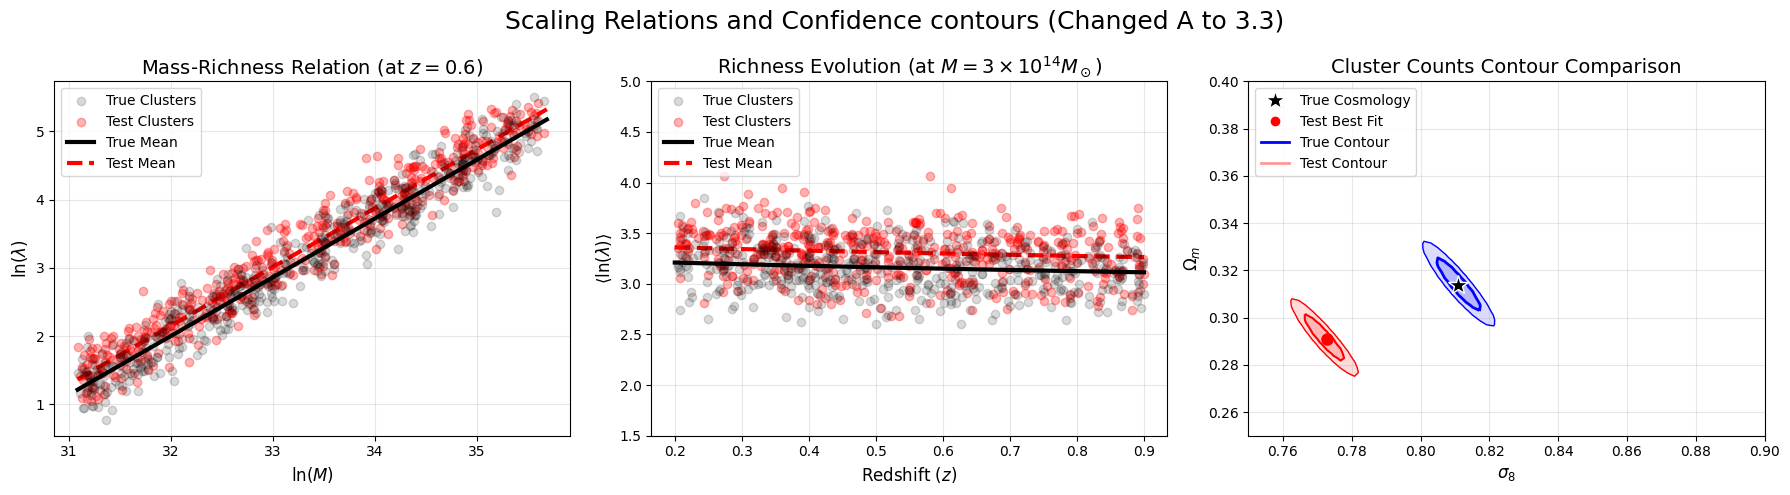

Elapsed Time: 594.9s


In [93]:
# Change A from 3.15 to 3.3 
start_time = time.time()

Plot_scaling(test_scaling_params=(3.3, 0.86, -0.21, 3e14, 0.6, 0.25), title_suffix="(Changed A to 3.3)")

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

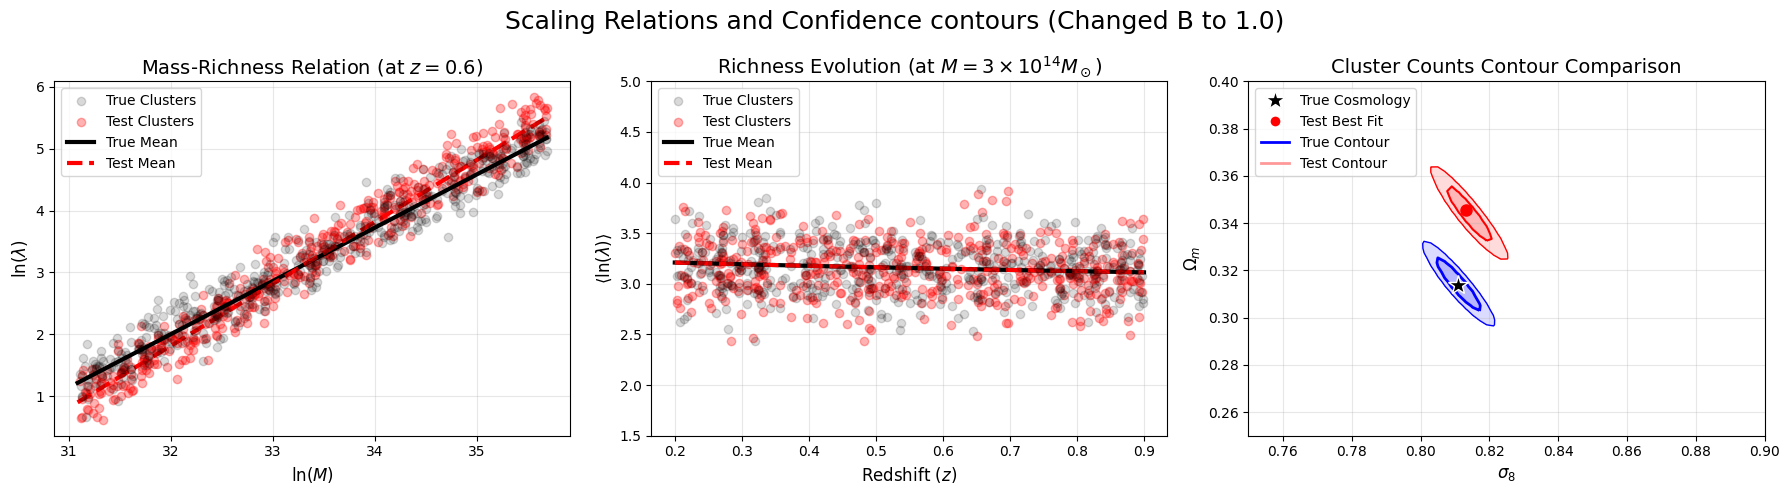

Elapsed Time: 498.3s


In [94]:
# Change B from 0.86 to 1.0 
start_time = time.time()

Plot_scaling(test_scaling_params=(3.15, 1, -0.21, 3e14, 0.6, 0.25), title_suffix="(Changed B to 1.0)")

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

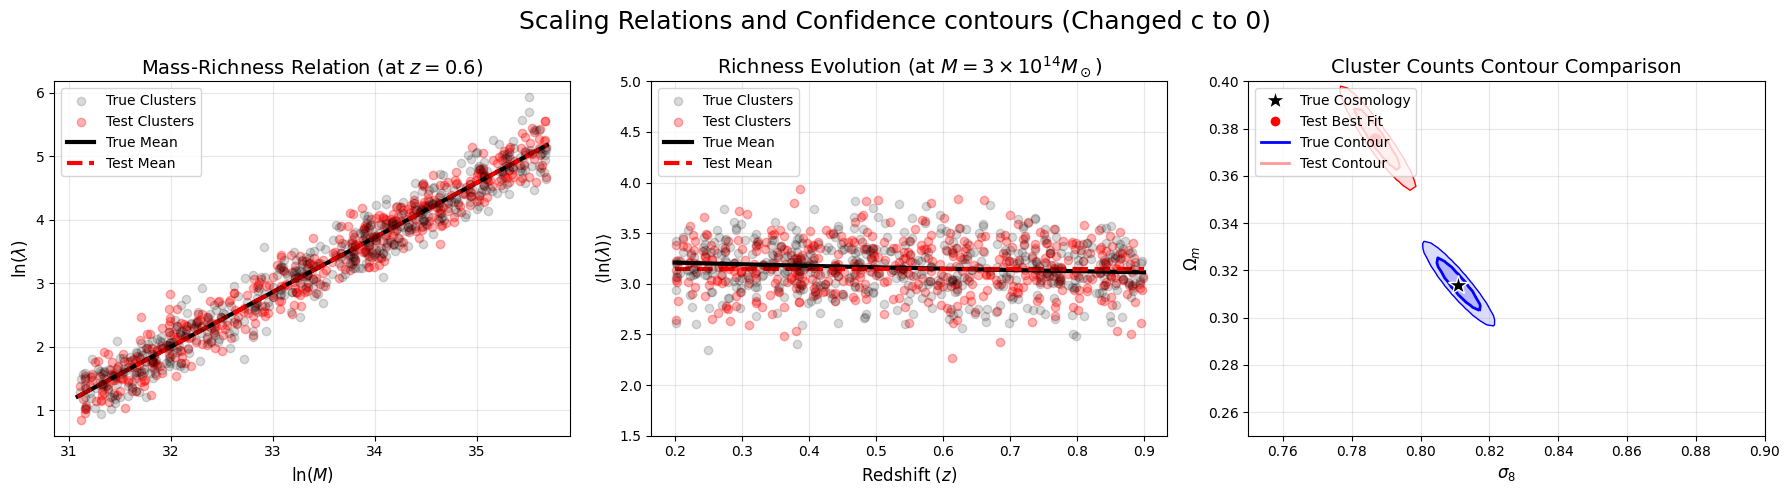

Elapsed Time: 653.8s


In [95]:
# Change C from -0.21 to 1.0 
start_time = time.time()

Plot_scaling(test_scaling_params=(3.15, 0.86, 0, 3e14, 0.6, 0.25), title_suffix="(Changed c to 0)")

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1169/715496174.py:4: SyntaxWarning: invalid escape sequence '\s'
  Plot_scaling(test_scaling_params=(3.15, 0.86, -0.21, 3e14, 0.6, 0.40), title_suffix="($\sigma_{ln_\lambda}$ to 0.40$)")


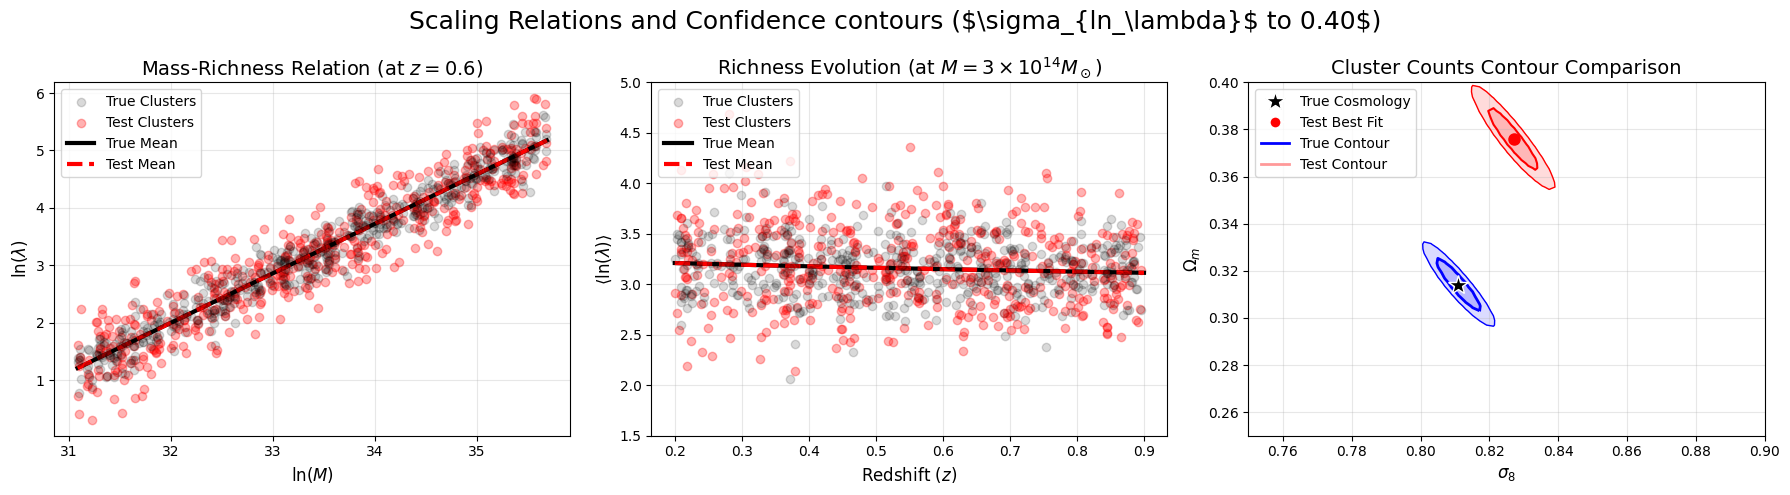

Elapsed Time: 590.4s


In [96]:
# Change sigma from 0.25 to 0.40
start_time = time.time()

Plot_scaling(test_scaling_params=(3.15, 0.86, -0.21, 3e14, 0.6, 0.40), title_suffix="($\sigma_{ln_\lambda}$ to 0.40$)")

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1169/772122578.py:4: SyntaxWarning: invalid escape sequence '\s'
  Plot_scaling(test_scaling_params=(3.15, 0.86, -0.21, 3e14, 0.6, 0.10), title_suffix="($\sigma_{ln_\lambda}$ to 0.10)")


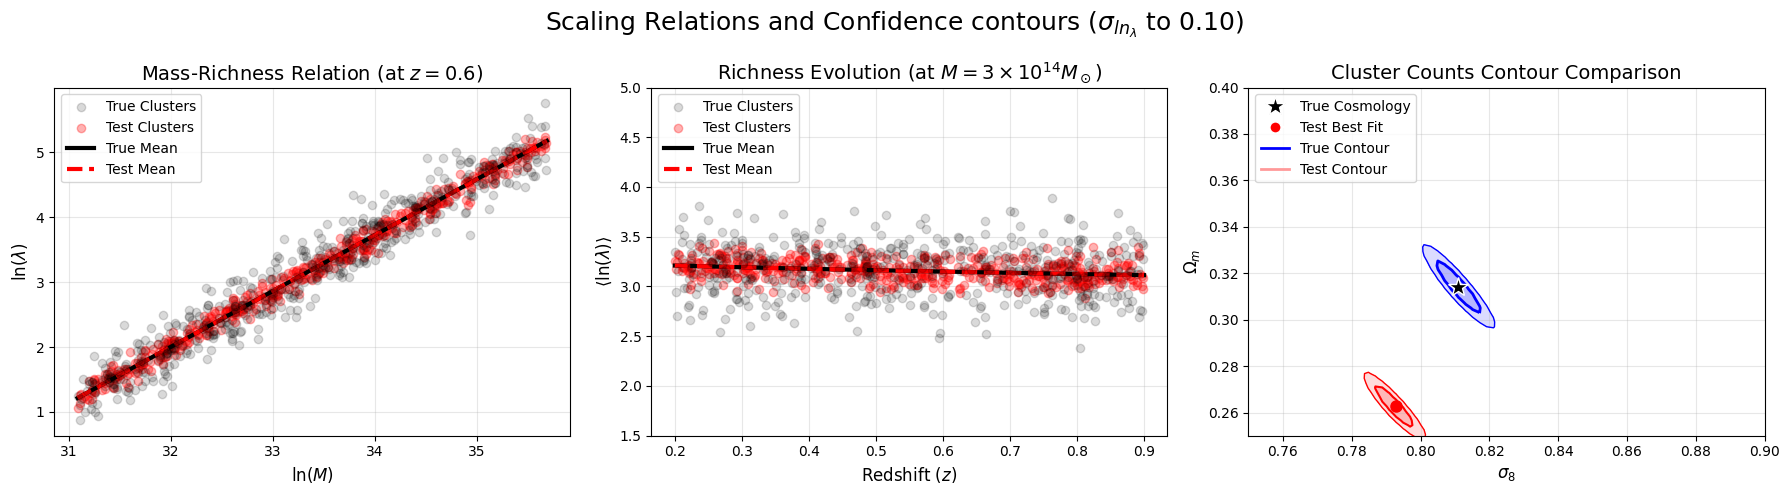

Elapsed Time: 585.1s


In [97]:
# Change sigma from 0.25 to 0.10
start_time = time.time()

Plot_scaling(test_scaling_params=(3.15, 0.86, -0.21, 3e14, 0.6, 0.10), title_suffix="($\sigma_{ln_\lambda}$ to 0.10)")

end_time = time.time()
print(f"Elapsed Time: {end_time - start_time:.1f}s")

## $S_8$ Parameter

The cosmological parameters $\Omega_m$ and $\sigma_8$ exhibit a strong degeneracy in cluster abundance analyses, leading to elongated confidence contours in the $\Omega_m$--$\sigma_8$ plane. To better constrain the growth of cosmic structure, a combined parameter $S_8$ is defined as

$$
S_8 \propto \sigma_8 \Omega_m^{\alpha}

$$

where $\alpha \approx 0.5$ is motivated by weak gravitational lensing studies, which are most sensitive to the combination $\sigma_8 \Omega_m^{0.5}$. Normalizing to the present-day matter density $\Omega_m = 0.3$ gives

$$
S_8 = \sigma_8 \sqrt{\frac{\Omega_m}{0.3}}

$$

Therefore, $S_8$ represents the combination of cosmological parameters $\Omega_m$ and $\sigma_8$ and is widely used for comparing cosmological constraints across different cosmological surveys.

sigma_8 * Omega_m^0.209 = 0.636
Degeneracy Slope (alpha) = 0.209
S_8 = 0.636


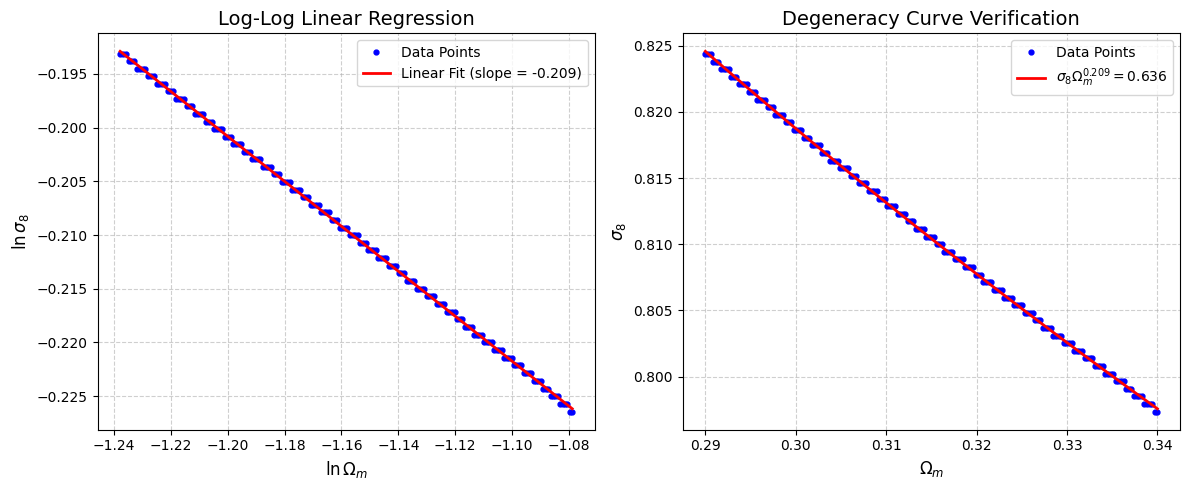

In [99]:
# ==========================================
# Extracting Parameter Degeneracy (2 bin)
# ==========================================
Om_ridge = []
s8_ridge = []

for i, Om_val in enumerate(Om_fine):
    min_idx = np.argmin(chi2_map_fine_7[i, :])
    if min_idx > 0 and min_idx < len(s8_fine) - 1:
        Om_ridge.append(Om_val)
        s8_ridge.append(s8_fine[min_idx])

Om_ridge = np.array(Om_ridge)
s8_ridge = np.array(s8_ridge)

log_Om = np.log(Om_ridge)
log_s8 = np.log(s8_ridge)

slope, intercept = np.polyfit(log_Om, log_s8, 1)

alpha = -slope
constant = np.exp(intercept)
S8 = constant 

print(f"sigma_8 * Omega_m^{alpha:.3f} = {constant:.3f}")
print(f"Degeneracy Slope (alpha) = {alpha:.3f}")
print(f"S_8 = {S8:.3f}")

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(log_Om, log_s8, 'bo', label='Data Points', markersize=3.5)
ax1.plot(log_Om, slope * log_Om + intercept, 'r-', linewidth=2, 
         label=f'Linear Fit (slope = {slope:.3f})')
ax1.set_xlabel(r'$\ln\Omega_m$', fontsize=12)
ax1.set_ylabel(r'$\ln\sigma_8$', fontsize=12)
ax1.set_title('Log-Log Linear Regression', fontsize=14)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(Om_ridge, s8_ridge, 'bo', label='Data Points', markersize=3.5)

smooth_Om = np.linspace(min(Om_ridge), max(Om_ridge), 100)
smooth_s8 = constant * (smooth_Om ** (-alpha))

ax2.plot(smooth_Om, smooth_s8, 'r-', linewidth=2, 
         label=rf'$\sigma_8 \Omega_m^{{{alpha:.3f}}} = {constant:.3f}$')
    
ax2.set_xlabel(r'$\Omega_m$', fontsize=12)
ax2.set_ylabel(r'$\sigma_8$', fontsize=12)
ax2.set_title('Degeneracy Curve Verification', fontsize=14)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [100]:
# Exact Solution
Om_true, s8_true, h, Ob, ns = 0.314, 0.811, 0.67, 0.049, 0.96
S_true_value = s8_true * (Om_true / 0.3)**0.5

print(f"Exact Solution for S8 at Omega_m=0.314: {S_true_value}")

Exact Solution for S8 at Omega_m=0.314: 0.8297075669575797
